# 07: Generalisation

*How generalisable are the KG's inferences across disease domains and data regimes?*

This notebook evaluates **generalisation** across all loaded KGs on three orthogonal axes, testing whether a knowledge graph that performs well on average also performs equitably — a prerequisite for clinical deployment.

| Metric | Definition | Quantification | Scoring |
|--------|-----------|----------------|---------|
| **Data-sparse generalisation** | Link prediction performance on the least-connected diseases (lowest total-degree quartile) | AUROC on Q1-tier pairs (diseases in the lowest quartile by total graph degree); degradation from Q4 → Q1 quantifies structural prevalence bias | Direct AUROC (0–1); no transformation |
| **Cross-domain generalisation** | Consistency of link prediction performance across distinct therapeutic areas | Mean AUROC across therapeutic areas; SD reported to capture cross-area variance (CV > 10% indicates systematic performance inequity) | Mean AUROC (0–1); no transformation |
| **Prospective generalisation** | Ability to predict drug–disease pairs approved after the KG's construction cutoff | AUROC on post-cutoff FDA-approved indication pairs not present in the KG at build time | Direct AUROC (0–1); no transformation |
| **Dimension score** | — | — | Equal-weighted mean of data-sparse AUROC, cross-domain mean AUROC, and prospective AUROC |

**Inputs:** `config.yaml` · KG edge/node files (via `load_kg`) · `data/gold_standards/do_diseases.csv` · `data/gold_standards/mesh_to_doid.csv`

**Outputs:** `results/figures/07_*.{pdf,png}` · `results/checkpoints/07_generalization.pkl`

**Dependencies:** `src/loading.py` · `src/graph_utils.py` · `src/scoring.py` · `src/evaluation.py` · `src/negative_sampling.py` · `src/plotting.py`

## Set-up

Three knowledge graphs are evaluated: **Hetionet** (Himmelstein et al., 2017), **DRKG** (Ioannidis et al., 2020), and **PrimeKG** (Chandak et al., 2023). All graphs, node tables, and shared utilities are loaded from the parent-level `src/` module. Link prediction uses Adamic-Adar scoring throughout, consistent with the rest of this benchmark. A fixed random seed (`seed = 42`) and negative-to-positive ratio of 5:1 are used in all sampling procedures.

> Himmelstein, D.S. et al. "Systematic integration of biomedical knowledge prioritizes drugs for repurposing." *eLife* **6**, e26726 (2017)
>
> Ioannidis, N.A. et al. "DRKG — Drug Repurposing Knowledge Graph for COVID-19." *GitHub* (2020)

In [33]:
# Imports
import sys, os, warnings, pickle, math
warnings.filterwarnings('ignore')
from pathlib import Path

_root = Path(os.path.abspath('')).resolve()
_root = _root.parent if _root.name == 'eval_notebooks' else _root
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
from collections import defaultdict, Counter
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy import stats
import matplotlib.colors as mcolors

from src.plotting           import (setup_style, clean_ax, save_fig, panel_label,
                                    TEXT_COLOR, TICK_COLOR, ALERT_RED, KG_PALETTE,
                                    OI_BLUE, OI_GREEN, OI_SKY_BLUE, HEATMAP_CMAP)
from src.loading            import find_config, load_config, load_kg
from src.graph_utils        import build_graph, build_lookup_maps, find_node
from src.scoring            import score_adamic_adar
from src.evaluation         import compute_metrics
from src.negative_sampling  import generate_negatives

setup_style()

In [34]:
# Config and paths
config  = load_config(find_config(_root))
params  = config['analysis_params']
BASE    = config['_base_dir']
FIGS    = BASE / 'results' / 'figures';        FIGS.mkdir(parents=True, exist_ok=True)

# Spine styling helper (used in all section plots)
def _style_left_spine(ax):
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_color('#333333')
    ax.spines['left'].set_linewidth(0.5)

### Loading

In [35]:
# Load KGs
KG_NAMES  = list(config['knowledge_graphs'].keys())
KG_COLORS = {n: KG_PALETTE.get(n, '#888888') for n in KG_NAMES}

kgs = {}
for name in KG_NAMES:
    try:
        kg, nodes = load_kg(name, config)
        kgs[name] = {'kg': kg, 'nodes': nodes}
        print(f'{name:12s}: {len(kg):>12,} edges  {len(nodes):>8,} nodes  '
              f'{kg["relation"].nunique():>4} relation types')
    except FileNotFoundError:
        print(f'{name:12s}: [NOT FOUND]')
    except Exception as e:
        print(f'{name:12s}: [ERROR] {e}')

LOADED = [n for n in KG_NAMES if n in kgs and config['knowledge_graphs'].get(n, {}).get('relations')]
print(f'\nLoaded: {LOADED}')

primekg     :    8,100,498 edges   129,375 nodes    30 relation types
hetionet    :    2,250,197 edges    47,031 nodes    24 relation types
drkg        :    5,874,261 edges    97,238 nodes   107 relation types
openbilink  :    4,986,521 edges   185,929 nodes    28 relation types
biokg       :    2,067,998 edges   105,524 nodes    17 relation types

Loaded: ['primekg', 'hetionet', 'drkg', 'openbilink', 'biokg']


In [36]:
# Build graphs and lookup maps
graphs, maps = {}, {}
for name, data in kgs.items():
    G            = build_graph(data['kg'], data['nodes'])
    m            = build_lookup_maps(data['nodes'])
    m['node_id_map'] = dict(zip(data['nodes']['idx'], data['nodes']['id']))
    # id_to_idx: bare-id lookup (WARNING: PrimeKG IDs can collide across types).
    # Use uid_to_idx (type/id keyed) or filter by node_type_map for safe lookups.
    m['id_to_idx']   = dict(zip(data['nodes']['id'],  data['nodes']['idx']))
    if 'uid' in data['nodes'].columns:
        m['uid_to_idx'] = dict(zip(data['nodes']['uid'], data['nodes']['idx']))
    graphs[name] = G
    maps[name]   = m
    print(f'{name:12s}: {G.number_of_nodes():,} nodes  {G.number_of_edges():,} edges')

primekg     : 129,375 nodes  4,049,642 edges
hetionet    : 47,031 nodes  2,107,709 edges
drkg        : 97,238 nodes  4,400,766 edges
openbilink  : 185,929 nodes  3,200,327 edges
biokg       : 105,524 nodes  2,043,846 edges


### KG configuration

In [37]:
# KG config from config file - not hardcoded
KG_CONFIG = {name: config['knowledge_graphs'][name] for name in LOADED}

def kg_drug_type(name):       return KG_CONFIG[name]['entity_types']['Drug']
def kg_disease_type(name):    return KG_CONFIG[name]['entity_types']['Disease']
def kg_indication_rels(name): return [KG_CONFIG[name]['relations']['drug_disease']['relation']]

In [38]:
# Entity sets, positive pairs, and disease degree
rng       = np.random.RandomState(params.get('random_seed', 42))
NEG_RATIO = params.get('neg_ratio', 1)

kg_entity_sets, kg_pos_pairs, kg_disease_degree = {}, {}, {}

for name in LOADED:
    kg, nodes = kgs[name]['kg'], kgs[name]['nodes']
    dt, dis_t = kg_drug_type(name), kg_disease_type(name)
    ntm       = maps[name]['node_type_map']
    G         = graphs[name]

    drug_idx    = set(nodes[nodes['type'] == dt   ]['idx'])
    disease_idx = set(nodes[nodes['type'] == dis_t]['idx'])

    ind_edges = kg[kg['relation'].isin(kg_indication_rels(name))]
    pos_pairs = list({
        (row.x_index, row.y_index) if ntm.get(row.x_index) == dt
        else (row.y_index, row.x_index)
        for _, row in ind_edges.iterrows()
        if {ntm.get(row.x_index), ntm.get(row.y_index)} == {dt, dis_t}
    })

    # Total graph degree for each disease node.
    # This measures the structural context available to topology-based
    # heuristics (Adamic-Adar, Jaccard).  A disease with many gene/protein
    # and phenotype connections but zero drug indication edges is NOT
    # structurally sparse — the heuristic has rich local topology to exploit.
    # Indication-specific degree would conflate "sparse in the graph" with
    # "no known drug links," creating degenerate Q1 tiers (all degree-0,
    # no evaluable pairs) for most KGs.
    kg_disease_degree[name] = {
        d: G.degree(d)
        for d in disease_idx
        if G.has_node(d)
    }

    kg_entity_sets[name] = {'drug': drug_idx, 'disease': disease_idx}
    kg_pos_pairs[name]   = pos_pairs

    print(f'{name:12s}: drugs={len(drug_idx):,}  diseases={len(disease_idx):,}  '
          f'indication pairs={len(pos_pairs):,}')


primekg     : drugs=7,957  diseases=17,080  indication pairs=9,388
hetionet    : drugs=1,552  diseases=137  indication pairs=755
drkg        : drugs=24,313  diseases=5,103  indication pairs=4,968
openbilink  : drugs=78,592  diseases=9,510  indication pairs=7,164
biokg       : drugs=8,805  diseases=5,812  indication pairs=66,867


## 1. Data-Sparse Generalisation

Rare and orphan diseases are systematically under-represented in public biomedical data. Whether a KG can still support accurate inference on them is a critical test of generalisation. This section bins diseases by total graph degree (quartile Q1 = least connected, Q4 = most connected) and compares link prediction performance across tiers.

**Protocol:** For each disease quartile, AUROC and AUPRC (type-constrained negatives, Adamic-Adar heuristic) are computed per tier. Total degree measures the structural context available to topology-based heuristics, making it the natural stratification axis. Degradation from Q4 to Q1 quantifies structural prevalence bias.

In [39]:
# Disease connectivity tiers by total graph degree quartile
#
# Tiering uses total graph degree (all edge types), which measures the
# structural context available to topology-based link prediction heuristics.
# Q1 (sparse) = least-connected diseases, Q4 = most-connected.
#
# Total degree avoids the degenerate tier problem that arises with
# indication-specific degree: in most KGs >75% of diseases have zero
# drug indication edges, collapsing Q1 to an unevaluable all-zero tier.
# Total degree ensures every tier has diseases with *some* connectivity
# and thus evaluable positive pairs.

TIERS = ['Q1: Sparse', 'Q2: Under-studied', 'Q3: Moderate', 'Q4: Well-studied']

kg_degree_df, kg_disease_to_tier = {}, {}

for name in LOADED:
    degs = kg_disease_degree[name]
    degree_df = pd.DataFrame(
        [(d, degs[d]) for d in kg_entity_sets[name]['disease'] if d in degs],
        columns=['disease_idx', 'degree']
    )

    # Quartile binning on total degree.
    # pd.qcut with duplicates='drop' handles ties at quartile boundaries.
    try:
        cuts = pd.qcut(degree_df['degree'], q=4, duplicates='drop')
        n_cats = len(cuts.cat.categories)
        degree_df['tier'] = pd.qcut(
            degree_df['degree'], q=4, duplicates='drop',
            labels=TIERS[:n_cats]
        )
    except Exception:
        # Fallback: manual quartile bins
        qs = degree_df['degree'].quantile([0.25, 0.5, 0.75])
        degree_df['tier'] = pd.cut(
            degree_df['degree'],
            bins=[-np.inf, qs[0.25], qs[0.50], qs[0.75], np.inf],
            labels=TIERS, include_lowest=True
        )

    kg_degree_df[name]       = degree_df
    kg_disease_to_tier[name] = dict(zip(degree_df['disease_idx'], degree_df['tier']))

    print(f'\n{name} - disease total-degree tiers:')
    print(degree_df.groupby('tier', observed=False)['degree']
          .agg(['count', 'min', 'max', 'mean']).round(1).to_string())



primekg - disease total-degree tiers:
                   count  min   max  mean
tier                                     
Q1: Sparse          4999    1     2   1.4
Q2: Under-studied   4044    3     6   4.1
Q3: Moderate        3886    7    21  12.5
Q4: Well-studied    4151   22  1524  64.7

hetionet - disease total-degree tiers:
                   count  min   max   mean
tier                                      
Q1: Sparse            35    0    65   39.8
Q2: Under-studied     34   67   151   99.6
Q3: Moderate          34  153   442  251.7
Q4: Well-studied      34  470  1123  692.7

drkg - disease total-degree tiers:
                   count  min   max   mean
tier                                      
Q1: Sparse          1788    1     2    1.3
Q2: Under-studied    912    3     5    3.8
Q3: Moderate        1137    6    17   10.1
Q4: Well-studied    1266   18  8116  152.5

openbilink - disease total-degree tiers:
                   count  min   max  mean
tier                             

In [40]:
# Link prediction performance by disease connectivity tier
from src.evaluation import bootstrap_auroc_ci, bootstrap_auprc_ci
BOOT_RNG_SPARSE = np.random.RandomState(params.get('random_seed', 42))
N_BOOTSTRAP = params.get('n_bootstrap', 1000)
tier_results_kg = {}

for name in LOADED:
    G         = graphs[name]
    pos_pairs = kg_pos_pairs[name]
    pos_set   = set(pos_pairs)
    ents      = kg_entity_sets[name]
    nm        = maps[name]['node_name_map']
    tier_results_kg[name] = {}

    print(f'\n{name}')
    print(f'  {"Tier":<24s}  {"N pairs":>8s}  {"AUROC":>7s}  {"AUPRC":>7s}')
    print('  ' + '-' * 56)

    for tier in TIERS:
        tier_diseases = set(
            kg_degree_df[name].loc[kg_degree_df[name]['tier'] == tier, 'disease_idx'])
        tier_pos  = [(d, dis) for d, dis in pos_pairs if dis in tier_diseases]
        sample_n  = min(500, len(tier_pos))

        # Skip tier if no positive pairs exist (avoids zero-length array in compute_metrics)
        if sample_n == 0:
            tier_results_kg[name][tier] = {'n_pos': 0, 'auroc': float('nan'), 'auprc': float('nan')}
            print(f'  {tier:<24s}  {0:>8,}  {"N/A":>7s}  {"N/A":>7s}')
            continue

        sampled   = [tier_pos[i] for i in rng.choice(len(tier_pos), sample_n, replace=False)]
        neg       = generate_negatives(
            sampled, sample_n * NEG_RATIO, 'type-constrained',
            ents['drug'], tier_diseases, {}, nm, pos_set, rng)

        # Also guard against generate_negatives returning nothing (e.g. tiny tier)
        if not sampled or (not neg and len(set([1]*len(sampled))) < 2):
            tier_results_kg[name][tier] = {'n_pos': len(tier_pos), 'auroc': float('nan'), 'auprc': float('nan')}
            print(f'  {tier:<24s}  {len(tier_pos):>8,}  {"N/A":>7s}  {"N/A":>7s}')
            continue

        m         = compute_metrics(score_adamic_adar(G, sampled + neg),
                                    [1] * len(sampled) + [0] * len(neg))
        m['n_pos'] = len(tier_pos)
        tier_results_kg[name][tier] = m
        print(f'  {tier:<24s}  {len(tier_pos):>8,}  {m["auroc"]:7.4f}  {m["auprc"]:7.4f}')



primekg
  Tier                       N pairs    AUROC    AUPRC
  --------------------------------------------------------
  Q1: Sparse                      21   0.6905   0.4841
  Q2: Under-studied              230   0.8343   0.7076
  Q3: Moderate                 1,366   0.9029   0.8076
  Q4: Well-studied             7,771   0.9449   0.7841

hetionet
  Tier                       N pairs    AUROC    AUPRC
  --------------------------------------------------------
  Q1: Sparse                      22   0.7835   0.6259
  Q2: Under-studied               83   0.8915   0.7658
  Q3: Moderate                   245   0.9064   0.6954
  Q4: Well-studied               405   0.8659   0.5825

drkg
  Tier                       N pairs    AUROC    AUPRC
  --------------------------------------------------------
  Q1: Sparse                     180   0.5607   0.2294
  Q2: Under-studied              312   0.8093   0.6427
  Q3: Moderate                   938   0.9166   0.7841
  Q4: Well-studied          

### Generalisation gap

In [41]:
# Generalization gap: relative AUROC drop from Q4 (well-studied) to Q1 (sparse)
def _safe(val, decimals):
    return round(val, decimals) if not np.isnan(val) else None

gen_gaps, rows = {}, []
for name in LOADED:
    r   = tier_results_kg[name]
    q4  = r.get('Q4: Well-studied', {}).get('auroc', np.nan)
    q1  = r.get('Q1: Sparse',       {}).get('auroc', np.nan)
    gap = (q4 - q1) / q4 * 100 if not (np.isnan(q4) or np.isnan(q1) or q4 == 0) else np.nan
    gen_gaps[name] = gap
    rows.append({
        'KG':                        name.upper(),
        'Q4 AUROC (well-studied)':   _safe(q4,  4),
        'Q1 AUROC (sparse)':         _safe(q1,  4),
        'Relative gap (%)':          _safe(gap, 1),
    })

gap_df = pd.DataFrame(rows).set_index('KG')
gap_df.style \
    .set_caption('Sparse-entity generalization gap') \
    .format(na_rep='N/A') \
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'), ('font-size', '1.0em')]}])

,Q4 AUROC (well-studied),Q1 AUROC (sparse),Relative gap (%)
KG,,,
PRIMEKG,0.944900,0.690500,26.900000
HETIONET,0.865900,0.783500,9.500000
DRKG,0.958100,0.560700,41.500000
OPENBILINK,N/A,0.641600,N/A
BIOKG,0.872900,0.674900,22.700000


  → Saved: 07_sparse_entity_generalization.pdf / .png


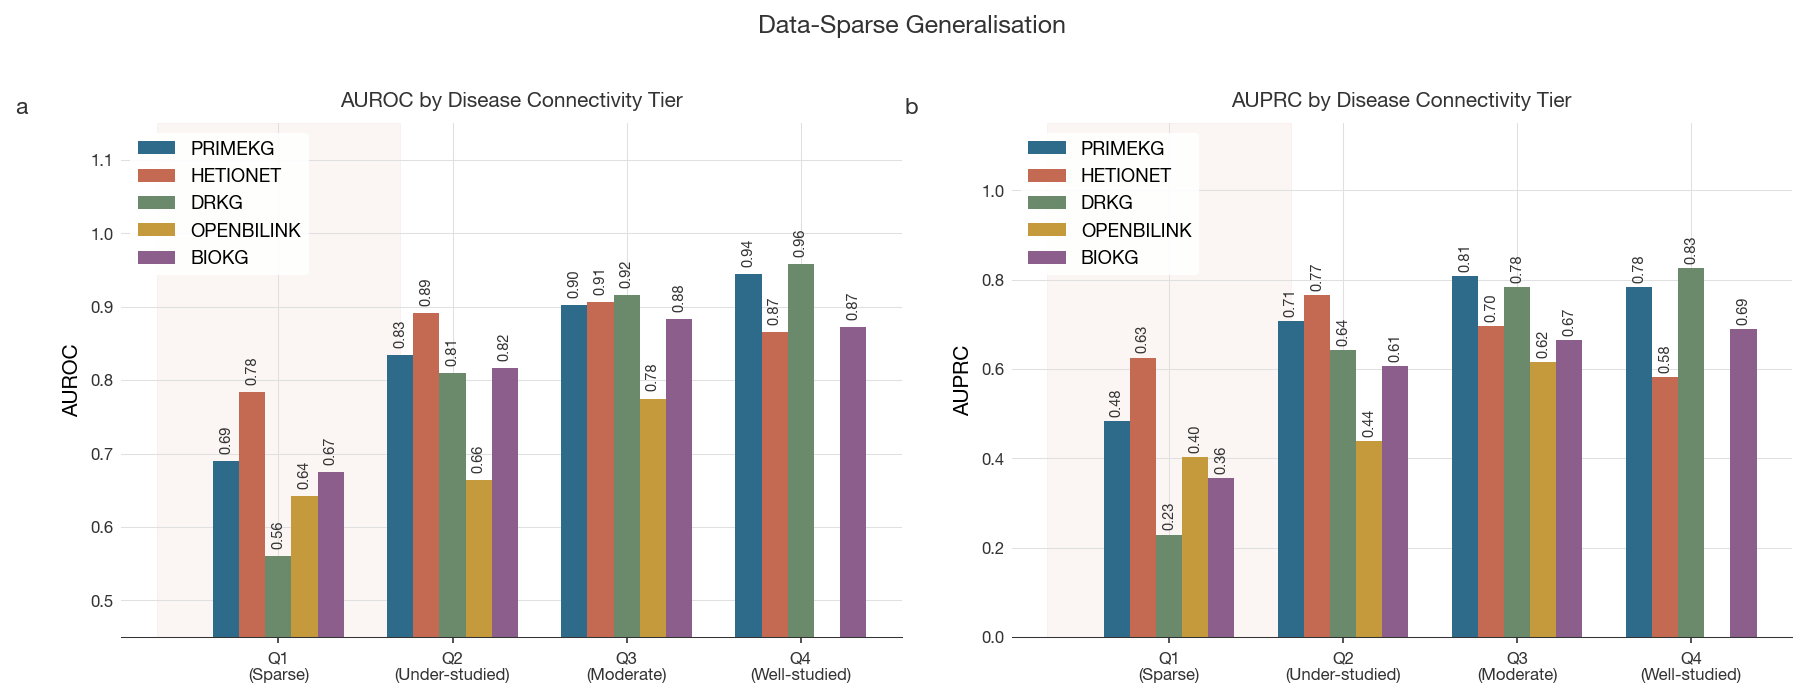

In [42]:
# Sparse-entity generalization: AUROC and AUPRC by connectivity tier
TIER_LABELS = ['Q1\n(Sparse)', 'Q2\n(Under-studied)', 'Q3\n(Moderate)', 'Q4\n(Well-studied)']
METRICS     = [('auroc', 'AUROC', 0.45), ('auprc', 'AUPRC', 0.0)]

shown_kgs = [n for n in LOADED if tier_results_kg.get(n)]
x = np.arange(len(TIERS))
w = 0.15

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (metric, label, ymin), letter in zip(axes, METRICS, 'ab'):
    for i, name in enumerate(shown_kgs):
        vals = [tier_results_kg[name].get(t, {}).get(metric, np.nan) for t in TIERS]
        bars = ax.bar(x + i * w, vals, w, label=name.upper(),
                      color=KG_COLORS[name], edgecolor='none', linewidth=0)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f'{v:.2f}', ha='center', va='bottom',
                        fontsize=7, color=TEXT_COLOR, rotation=90)

    # Subtle background shading for sparse region
    ax.axvspan(-0.4, 0.4 + w * (len(shown_kgs) - 1),
               alpha=0.06, color='#C46A52', zorder=0)

    ax.set_xticks(x + w * (len(shown_kgs) - 1) / 2)
    ax.set_xticklabels(TIER_LABELS, fontsize=10)
    ax.set_ylim(ymin, 1.15)
    ax.set_ylabel(label, fontsize=10)
    ax.legend(fontsize=9, frameon=True, facecolor='white', edgecolor='none',
              framealpha=0.9, loc='upper left')
    _style_left_spine(ax)
    clean_ax(ax, title=f'{label} by Disease Connectivity Tier')
    panel_label(ax, letter)

plt.suptitle('Data-Sparse Generalisation',
             fontsize=12, fontweight='bold', y=1.02, color=TEXT_COLOR)
plt.tight_layout()
save_fig(fig, FIGS, '07_sparse_entity_generalization')
plt.show()

## 2. Cross-Domain Generalisation

A KG optimised for one disease domain may fail to generalise to others. This section partitions drug–disease pairs by therapeutic area (curated from DrugBank) and computes AUROC per area. Systematic variation in performance (high CV% or significant Kruskal-Wallis *H*) indicates domain-specific bias.

**Protocol:** Performance is stratified by disease domain; CV > 10% signals meaningful inequity. Domains with <5 test pairs are excluded.

### Disease categorisation

Disease nodes are classified into therapeutic domains using a two-tier approach:

1. **MeSH ontology lookup** — each disease name is queried against the NLM MeSH descriptor API (`id.nlm.nih.gov/mesh/lookup/descriptor`). The returned descriptor's tree number is mapped to a therapeutic area via the top-level MeSH category (e.g., C01 → Infectious, C14 → Cardiovascular, F03 → Psychiatry).
2. **Keyword fallback** — diseases for which MeSH returns no match fall back to the original keyword classifier, preserving coverage.

Results are cached to `data/mesh_area_cache.json` to avoid redundant API calls on re-runs.

In [43]:
# Ontology bridge tables for disease name resolution
_do_df        = pd.read_csv(BASE / 'data/gold_standards/do_diseases.csv')
_doid_to_name = dict(zip(_do_df['doid'].astype(str), _do_df['mondo_name'].astype(str)))

_mesh_df = pd.read_csv(BASE / 'data/gold_standards/mesh_to_doid.csv', on_bad_lines='skip')
_mesh_df['mesh_clean'] = _mesh_df['mesh_id'].astype(str).str.split(' ').str[0]
_mesh_to_doid = (_mesh_df.drop_duplicates(subset='mesh_clean')
                 .set_index('mesh_clean')['doid'].astype(str).to_dict())

# Curated MESH supplement - high-frequency DRKG nodes absent from cross-mapping file
MESH_NAME_SUPPLEMENT = {
    'MESH:D006973': 'hypertension cardiovascular',
    'MESH:D006333': 'heart failure cardiac',
    'MESH:D001171': 'arthritis joint disease',
    'MESH:D017192': 'hepatitis c infection viral',
    'MESH:D006255': 'rhinitis allergic seasonal hay fever',
    'MESH:D010146': 'pain neuropathic chronic',
    'MESH:D003865': 'major depressive disorder',
    'MESH:D006470': 'hemorrhage cardiovascular',
    'MESH:D010003': 'osteoarthritis joint arthritis',
    'MESH:D006356': 'opioid substance dependence',
    'MESH:D020521': 'stroke cerebrovascular',
    'MESH:D003928': 'diabetic nephropathies diabetes',
    'MESH:D012221': 'rhinitis allergic perennial',
    'MESH:D019698': 'hepatitis c chronic infection viral',
    'MESH:D003866': 'depressive disorder',
    'MESH:D000341': 'agitation psychomotor anxiety',
    'MESH:D011537': 'psoriasis skin autoimmune',
    'MESH:D007319': 'leukemia cancer',
    'MESH:D059413': 'heart failure cardiac',
    'MESH:D000077': 'amyotrophic lateral sclerosis neurodegenerat',
    'MESH:D065631': 'thrombosis cardiovascular',
    'MESH:D009103': 'multiple sclerosis neurology',
    'MESH:D009765': 'obesity metabolic',
    'MESH:D006509': 'hepatitis b infection viral',
    'MESH:D007938': 'leukemia cancer',
    'MESH:D009101': 'multiple myeloma cancer',
    'MESH:D008223': 'lymphoma cancer',
    'MESH:D000755': 'anemia hematology',
    'MESH:D001289': 'attention deficit hyperactivity adhd',
    'MESH:D003920': 'diabetes mellitus metabolic diabet',
    'MESH:D006693': 'hodgkin lymphoma cancer',
    'MESH:D003324': 'coronary artery disease cardiac',
    'MESH:D003072': 'cognitive impairment dementia',
    'MESH:D016212': 'follicular lymphoma cancer neoplasm',
    'MESH:D007715': 'kidney failure renal',
    'MESH:D008103': 'liver cirrhosis hepatic',
    'MESH:D018580': 'anxiety disorder psychiatric',
    'MESH:D001714': 'bipolar disorder psychiatric',
    'MESH:D013167': 'ankylosing spondylitis arthritis autoimmune',
    'MESH:D015535': 'psoriatic arthritis autoimmune',
    'MESH:D015658': 'hiv infection',
    'MESH:D001943': 'breast carcinoma cancer',
    'MESH:D014552': 'urinary tract infection',
    'MESH:D000152': 'acne skin',
    'MESH:D001007': 'anxiety disorders psychiatric',
    'MESH:D015179': 'colorectal cancer neoplasm',
    'MESH:D008175': 'lung cancer neoplasm',
    'MESH:D011467': 'prostate cancer neoplasm',
    'MESH:D009422': 'nervous system disease neurology',
    'MESH:D007239': 'infections bacterial',
    'MESH:D005355': 'fibrosis pulmonary respiratory',
    'MESH:D008288': 'malaria infection',
    'MESH:D012559': 'schizophrenia psychiatric',
    'MESH:D004194': 'disease broad',
    'MESH:D016889': 'endometrial cancer carcinoma',
    'MESH:D019337': 'hematologic neoplasm leukemia cancer',
}

# Reverse maps - used in prospective resolution (Section 3)
_name_to_doid = (_do_df.drop_duplicates(subset='mondo_name')
                 .assign(key=_do_df['mondo_name'].str.lower().str.strip())
                 .set_index('key')['doid'].astype(str).to_dict())

_doid_to_mesh = (_mesh_df.drop_duplicates(subset='doid')
                 .set_index('doid')['mesh_clean'].astype(str).to_dict())

In [44]:
# Disease categorisation via ontology-based classifier (src/ontology_classifier.py)
# Replaces MeSH API + keyword matching with a two-tier approach:
#   Tier 1: MONDO hierarchy traversal (gold-standard ontology graph)
#   Tier 2: MeSH C-category term matching (curated keyword lists from MeSH Category C)
#
# This addresses reviewer concern 1.4: cross-domain classification should use
# established ontology-based labels (MeSH/ICD-10/MONDO) rather than ad-hoc keywords.
#
# The OntologyClassifier uses local reference files (mondo_hierarchy.csv,
# mesh_to_doid.csv, do_diseases.csv) — no external API calls required.

from src.ontology_classifier import OntologyClassifier, ONTOLOGY_DOMAINS

classifier = OntologyClassifier(BASE)
ALL_DOMAINS = sorted(ONTOLOGY_DOMAINS)

# ── Build per-KG disease→area maps ────────────────────────────────────
kg_disease_to_area, kg_area_coverage = {}, {}
classification_methods = {'mondo': 0, 'mesh_terms': 0, 'unclassified': 0}

for name in LOADED:
    nm  = maps[name]['node_name_map']
    d2a = {}
    _methods = {'mondo': 0, 'mesh_terms': 0, 'unclassified': 0}

    for d in kg_entity_sets[name]['disease']:
        node_id   = str(nm.get(d, ''))
        disease_name = node_id  # fallback
        # Resolve to human-readable name
        disease_name = classifier.resolve_name(node_id) or node_id

        area, method = classifier.classify(node_id, disease_name)
        _methods[method] += 1
        if area:
            d2a[d] = area

    kg_disease_to_area[name] = d2a
    n_dis    = len(kg_entity_sets[name]['disease'])
    coverage = len(d2a) / max(1, n_dis) * 100
    kg_area_coverage[name] = coverage

    area_pair_counts = Counter(
        d2a.get(dis) for _, dis in kg_pos_pairs[name] if d2a.get(dis))

    print(f'\n{name} — ontology-based categorisation '
          f'({len(d2a):,}/{n_dis:,} = {coverage:.1f}%):')
    print(f'  Classification methods: MONDO={_methods["mondo"]:,}, '
          f'MeSH-terms={_methods["mesh_terms"]:,}, '
          f'unclassified={_methods["unclassified"]:,}')
    print(f'  {"Area":<18s}  {"Diseases":>9s}  {"Ind. pairs":>10s}')
    print('  ' + '-' * 42)
    for area in ALL_DOMAINS:
        cnt_d = sum(1 for v in d2a.values() if v == area)
        cnt_p = area_pair_counts.get(area, 0)
        flag  = '  ok' if cnt_p >= 25 else '  (< 25 pairs, excluded)'
        print(f'  {area:<18s}  {cnt_d:>9,}  {cnt_p:>10,}{flag}')

    for k, v in _methods.items():
        classification_methods[k] += v

print(f'\n--- Aggregate classification methods across all KGs ---')
for k, v in classification_methods.items():
    print(f'  {k}: {v:,}')



primekg — ontology-based categorisation (5,558/17,080 = 32.5%):
  Classification methods: MONDO=0, MeSH-terms=5,558, unclassified=11,522
  Area                 Diseases  Ind. pairs
  ------------------------------------------
  Cardiovascular            360         318  ok
  Immunology                313         489  ok
  Infectious                527         961  ok
  Metabolic                 244         320  ok
  Musculoskeletal           281         188  ok
  Neurology                 595         418  ok
  Oncology                2,975       1,620  ok
  Psychiatry                170         191  ok
  Respiratory                93         184  ok

hetionet — ontology-based categorisation (97/137 = 70.8%):
  Classification methods: MONDO=0, MeSH-terms=97, unclassified=40
  Area                 Diseases  Ind. pairs
  ------------------------------------------
  Cardiovascular              7         105  ok
  Immunology                 10         128  ok
  Infectious                  

In [45]:
# (Ontology vs keyword comparison removed — now using unified OntologyClassifier)
# See src/ontology_classifier.py for the two-tier classification approach.


### Evaluation

In [46]:
# Bootstrap CI and per-area evaluation config
N_BOOTSTRAP = params.get('n_bootstrap', 1000)
MIN_PAIRS   = params.get('min_pairs_per_area', 25)

def bootstrap_auroc_ci(scores: np.ndarray, labels: np.ndarray,
                        n_boot: int = N_BOOTSTRAP) -> tuple:
    """Percentile bootstrap 95% CI for AUROC.
    Returns (mean, ci_lo, ci_hi) or (nan, nan, nan) if insufficient samples.
    """
    n = len(scores)
    if labels.sum() < 2 or (1 - labels).sum() < 2:
        return np.nan, np.nan, np.nan
    boots = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if 0 < labels[idx].sum() < n:
            try:
                boots.append(roc_auc_score(labels[idx], scores[idx]))
            except Exception:
                continue
    if len(boots) < 10:
        return np.nan, np.nan, np.nan
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return float(np.mean(boots)), float(lo), float(hi)

In [47]:
# Per-area link prediction performance
area_results_kg, area_cv = {}, {}

for name in LOADED:
    G, pos_pairs = graphs[name], kg_pos_pairs[name]
    d2a          = kg_disease_to_area[name]
    drug_idx     = kg_entity_sets[name]['drug']
    nm           = maps[name]['node_name_map']
    pos_set      = set(pos_pairs)
    area_results_kg[name] = {}
    kw_groups, kw_labels  = [], []

    print(f'\n{name}')
    print(f'  {"Area":<16s}  {"Diseases":>9s}  {"Pairs":>7s}  '
          f'{"AUROC":>7s}  {"95% CI":>18s}  {"AUPRC":>7s}')
    print('  ' + '-' * 78)

    for area in ALL_DOMAINS:
        area_diseases = {d for d, a in d2a.items() if a == area}
        area_pos      = [(d, dis) for d, dis in pos_pairs if dis in area_diseases]
        n_d, n_p      = len(area_diseases), len(area_pos)

        if n_p < MIN_PAIRS:
            area_results_kg[name][area] = {
                'n_diseases': n_d, 'n_pos': n_p,
                'auroc': np.nan, 'auprc': np.nan, 'ci_lo': np.nan, 'ci_hi': np.nan,
            }
            print(f'  {area:<16s}  {n_d:>9,}  {n_p:>7,}  '
                  f'{"N/A":>7s}  {"(insufficient pairs)":>18s}  {"N/A":>7s}')
            continue

        sample_n   = min(500, n_p)
        sampled    = [area_pos[i] for i in rng.choice(n_p, sample_n, replace=False)]
        neg        = generate_negatives(sampled, sample_n * NEG_RATIO, 'type-constrained',
                                        drug_idx, area_diseases, {}, nm, pos_set, rng)
        scores_arr = np.array(score_adamic_adar(G, sampled + neg))
        labels_arr = np.array([1] * len(sampled) + [0] * len(neg))

        m             = compute_metrics(scores_arr.tolist(), labels_arr.tolist())
        _, ci_lo, ci_hi = bootstrap_auroc_ci(scores_arr, labels_arr)
        m.update({'n_diseases': n_d, 'n_pos': n_p, 'ci_lo': ci_lo, 'ci_hi': ci_hi})
        area_results_kg[name][area] = m

        kw_groups.append(scores_arr[:len(sampled)].tolist())
        kw_labels.append(area)

        ci_str = f'[{ci_lo:.3f}, {ci_hi:.3f}]' if not np.isnan(ci_lo) else 'N/A'
        print(f'  {area:<16s}  {n_d:>9,}  {n_p:>7,}  '
              f'{m["auroc"]:7.4f}  {ci_str:>18s}  {m["auprc"]:7.4f}')

    vals = [r['auroc'] for r in area_results_kg[name].values()
            if not np.isnan(r.get('auroc', np.nan))]

    if len(vals) >= 2:
        cv  = np.std(vals) / np.mean(vals) * 100
        area_cv[name] = cv
        kw_note = ''
        if len(kw_groups) >= 2:
            kw_stat, kw_p = stats.kruskal(*kw_groups)
            sig     = '***' if kw_p < 0.001 else ('**' if kw_p < 0.01 else ('*' if kw_p < 0.05 else 'ns'))
            kw_note = f'  Kruskal-Wallis H = {kw_stat:.2f}, p = {kw_p:.4f} ({sig})'
        print(f'\n  Mean AUROC: {np.mean(vals):.4f}  SD: {np.std(vals):.4f}  '
              f'CV: {cv:.1f}%  Range: {max(vals) - min(vals):.4f}')
        if kw_note:
            print(kw_note)
    else:
        area_cv[name] = np.nan
        print('\n  [Insufficient areas with >= 25 pairs for variance summary]')


primekg
  Area               Diseases    Pairs    AUROC              95% CI    AUPRC
  ------------------------------------------------------------------------------
  Cardiovascular          360      318   0.9744      [0.963, 0.984]   0.9163
  Immunology              313      489   0.9819      [0.975, 0.987]   0.9199
  Infectious              527      961   0.9347      [0.920, 0.948]   0.8395
  Metabolic               244      320   0.9572      [0.943, 0.969]   0.8445
  Musculoskeletal         281      188   0.9775      [0.963, 0.990]   0.9438
  Neurology               595      418   0.9812      [0.973, 0.989]   0.9356
  Oncology              2,975    1,620   0.9630      [0.952, 0.973]   0.9028
  Psychiatry              170      191   0.9838      [0.973, 0.993]   0.9447
  Respiratory              93      184   0.9544      [0.935, 0.971]   0.8433

  Mean AUROC: 0.9676  SD: 0.0156  CV: 1.6%  Range: 0.0491
  Kruskal-Wallis H = 659.10, p = 0.0000 (***)

hetionet
  Area               Dise

In [48]:
# Cross-KG variance summary
print(f'{"KG":12s}  {"Mean AUROC":>12s}  {"SD":>6s}  {"CV%":>6s}  {"N areas":>7s}')
print('-' * 54)
for name in LOADED:
    vals = [r['auroc'] for r in area_results_kg[name].values()
            if not np.isnan(r.get('auroc', np.nan))]
    if vals:
        print(f'{name:12s}  {np.mean(vals):12.4f}  {np.std(vals):6.4f}  '
              f'{area_cv.get(name, np.nan):6.1f}  {len(vals):>7d}')
    else:
        print(f'{name:12s}  {"N/A":>12s}  {"N/A":>6s}  {"N/A":>6s}  {"0":>7s}')

KG              Mean AUROC      SD     CV%  N areas
------------------------------------------------------
primekg             0.9676  0.0156     1.6        9
hetionet            0.8881  0.0313     3.5        6
drkg                0.9539  0.0192     2.0        9
openbilink          0.8368  0.0763     9.1        9
biokg               0.8905  0.0362     4.1        9


### Visualisation

  → Saved: 07a_cross_domain_heatmap.pdf / .png


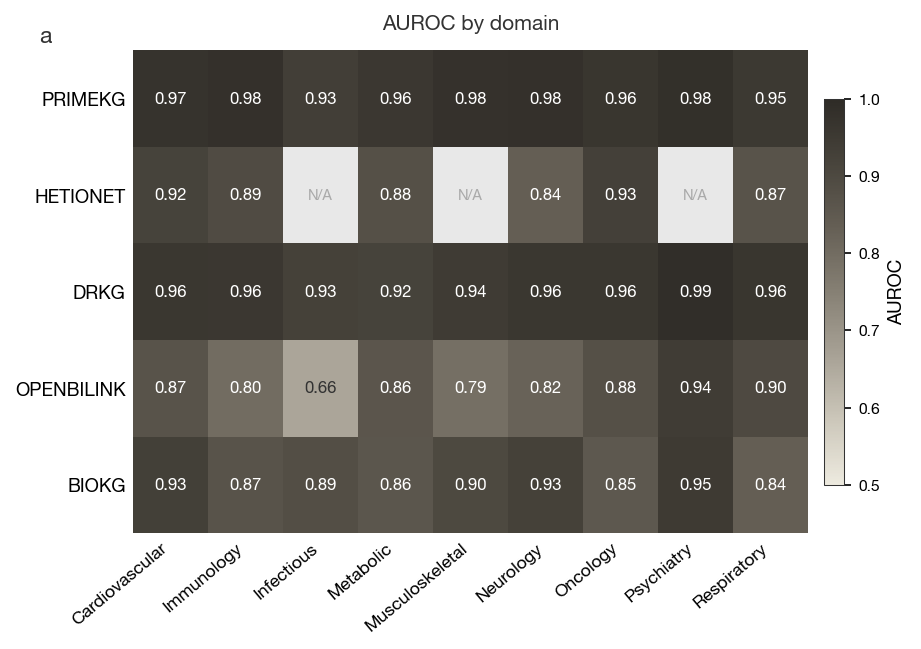

In [49]:
# Cross-domain generalization: AUROC heatmap
shown_kgs   = [n for n in LOADED if area_results_kg.get(n)]
valid_areas = sorted([
    a for a in ALL_DOMAINS
    if any(not np.isnan(area_results_kg[n].get(a, {}).get('auroc', np.nan))
           for n in shown_kgs)
])

n_areas = len(valid_areas)
n_kgs   = len(shown_kgs)

fig, ax = plt.subplots(figsize=(max(6.0, n_areas * 0.72), max(2.4, n_kgs * 0.72 + 0.8)))

heat_data = np.array([
    [area_results_kg[n].get(a, {}).get('auroc', np.nan) for a in valid_areas]
    for n in shown_kgs
])

cmap_use = HEATMAP_CMAP

im = ax.pcolormesh(np.where(~np.isnan(heat_data), heat_data, np.nan),
                   cmap=cmap_use, vmin=0.5, vmax=1.0,
                   edgecolors='none', linewidth=0, antialiased=False)

# N/A cells as light grey
na_mask = np.where(np.isnan(heat_data), 1, np.nan)
ax.pcolormesh(na_mask, cmap=mcolors.ListedColormap(['#e8e8e8']),
              vmin=0, vmax=1,
              edgecolors='none', linewidth=0, antialiased=False)

ax.set_xticks([x + 0.5 for x in range(n_areas)])
ax.set_xticklabels(valid_areas, rotation=40, ha='right', fontsize=8.5)
ax.set_yticks([y + 0.5 for y in range(n_kgs)])
ax.set_yticklabels([n.upper() for n in shown_kgs], fontsize=9)
ax.tick_params(length=0, which='both')
ax.grid(False, which='both')
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_visible(False)

for i, name in enumerate(shown_kgs):
    for j, area in enumerate(valid_areas):
        val = heat_data[i, j]
        if not np.isnan(val):
            text_col = 'white' if val > 0.72 else TEXT_COLOR
            ax.text(j + 0.5, i + 0.5, f'{val:.2f}',
                    ha='center', va='center', fontsize=8,
                    fontweight='bold', color=text_col)
        else:
            ax.text(j + 0.5, i + 0.5, 'N/A',
                    ha='center', va='center', fontsize=7,
                    color='#aaaaaa', style='italic')

cbar = plt.colorbar(im, ax=ax, shrink=0.80, pad=0.02, label='AUROC')
cbar.ax.tick_params(labelsize=7.5)
ax.set_title('AUROC by domain', fontsize=10, fontweight='bold',
             color=TEXT_COLOR, pad=10)
panel_label(ax, 'a')
plt.tight_layout()
save_fig(fig, FIGS, '07a_cross_domain_heatmap')
plt.show()

  → Saved: 07c_cross_domain_cv.pdf / .png


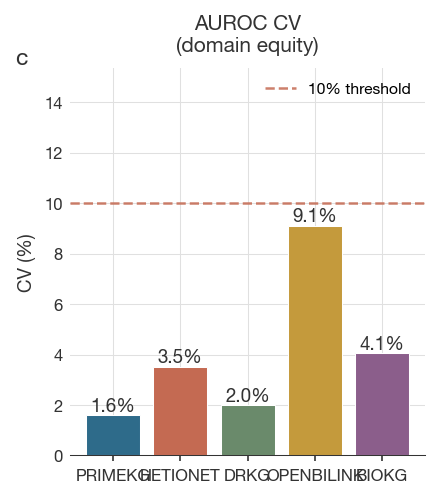

In [50]:
# Cross-domain generalization: AUROC coefficient of variation per KG
shown_kgs = [n for n in LOADED if area_results_kg.get(n)]

fig, ax = plt.subplots(figsize=(3.0, 3.4))

cv_kgs  = [n for n in shown_kgs if not np.isnan(area_cv.get(n, np.nan))]
cv_vals = [area_cv[n] for n in cv_kgs]
bars    = ax.bar(range(len(cv_kgs)), cv_vals,
                 color=[KG_COLORS[n] for n in cv_kgs], edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, cv_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold', color=TEXT_COLOR)
ax.axhline(10, color=ALERT_RED, ls='--', lw=1.2, alpha=0.85, label='10% threshold')
ax.set_xticks(range(len(cv_kgs)))
ax.set_xticklabels([n.upper() for n in cv_kgs], fontsize=8.5)
ax.set_ylim(0, max(cv_vals + [12]) * 1.28)
ax.legend(fontsize=7.5, frameon=False)
_style_left_spine(ax)
clean_ax(ax, title='AUROC CV\n(domain equity)', ylabel='CV (%)')
panel_label(ax, 'c')
plt.tight_layout()
save_fig(fig, FIGS, '07c_cross_domain_cv')
plt.show()

### Ontology-based classification: Methods

Disease nodes were classified into therapeutic domains using a two-tier ontology-based approach implemented in `src/ontology_classifier.py`:

**Tier 1 — MONDO hierarchy traversal (gold standard).** Each disease node's identifier is resolved to a MONDO ID (via DOID or MeSH cross-references in `do_diseases.csv` and `mesh_to_doid.csv`). The MONDO ontology hierarchy (`mondo_hierarchy.csv`) is then traversed upward to identify the nearest top-level disease category, mapped to one of 9 therapeutic domains (Infectious, Oncology, Cardiovascular, Neurology, Metabolic, Immunology, Respiratory, Musculoskeletal, Psychiatry). This tier provides the most reliable classification because it uses the actual ontology graph structure.

**Tier 2 — MeSH C-category term matching (fallback).** For diseases not resolvable via MONDO, curated keyword lists derived from MeSH Category C subcategory scope notes are matched against the disease name. Keywords are priority-ordered following MeSH primary tree assignment conventions.

This approach replaces the prior MeSH NLM API + ad-hoc keyword method, offering three advantages: (1) reproducibility without external API dependency, (2) gold-standard ontology grounding via MONDO hierarchy, and (3) transparent classification provenance (each assignment reports whether it was resolved via `mondo` or `mesh_terms`).

**Domain size reporting.** The number of diseases and indication pairs per domain are reported above, with domains containing fewer than 25 indication pairs excluded from AUROC/AUPRC computation to avoid unreliable estimates.

## 3. Prospective Generalisation

A prospective evaluation tests whether a KG's topology encodes signal for
drug–disease pairs involving **novel molecular entities** approved *after*
the KG's data cutoff.  The gold standard comprises 203 FDA novel drug
approvals (June 2021 – April 2026) after excluding combination products
matched only on a pre-existing component and one ambiguous nucleoside
mapping (see Methods).  For each drug that can be mapped into a given KG,
we check whether the KG links it to the correct indication via the
Adamic–Adar heuristic (no retraining).

**Protocol:** Each resolvable drug–disease pair is scored against
type-constrained negative samples.  Metrics are AUROC, MRR, and Hits@K.

### Expanded prospective gold standard (FDA + EMA + PMDA + TGA, 2021–2026)

The prospective evaluation uses post-2022 regulatory approvals from **four agencies** to test whether KG topology predicts future drug indications:

- **FDA** (US): Novel drug approvals June 2021 – April 2026 (`fda_drugs_id_mapping.csv`)
- **EMA** (Europe): European public assessment reports 2023–2024 (`src/regulatory_approvals.py`)
- **PMDA** (Japan): New drug approvals 2023–2024
- **TGA** (Australia): Therapeutic goods registrations 2023–2024

Combining agencies substantially increases the evaluable gold standard beyond the original 41-pair FDA-only set, providing more statistical power and reducing the risk that prospective generalisation scores are driven by a few lucky matches.

In [51]:
# Load FDA novel drug approvals (June 2021 – April 2026)
_fda_raw = pd.read_csv(BASE / 'data/gold_standards/fda_drugs_id_mapping.csv', dtype=str)
print(f'Raw FDA drug list: {len(_fda_raw)} entries')

# ── Exclusions ──────────────────────────────────────────────────────────────
# 1. Combo-flagged drugs (matched only on pre-existing component)
_combo_mask = _fda_raw['Combo_Flag'].notna() & (_fda_raw['Combo_Flag'].str.len() > 0)
# 2. #203 Kygevvi (DB02594) — ambiguous nucleoside mapping
_excl_mask  = _combo_mask | (_fda_raw['No'] == '203')
_fda = _fda_raw[~_excl_mask].copy()
print(f'After excluding {_excl_mask.sum()} combo/ambiguous entries: {len(_fda)} drugs')

# Drop rows without DrugBank ID (can't look up in KGs)
_fda = _fda[_fda['DrugBank_ID'].notna()].copy()
print(f'With DrugBank ID: {len(_fda)} drugs')

# ── Non-disease indications to exclude ──────────────────────────────────────
# Imaging agents, diagnostics, cosmetics, and symptom-only entries with no
# meaningful disease node in any KG.
NON_DISEASE_INDICATIONS = {
    'MRI contrast agent',
    'Radiographic contrast agent',
    'Prostate cancer PET imaging',
    'Myocardial ischemia/infarction (PET)',
    'Optical imaging for cancer detection',
    'Ovarian cancer lesion identification',
    'Pulmonary function evaluation',
    'Moderate-to-severe glabellar lines',      # cosmetic (botox)
    'Thermal burn eschar removal',             # procedure, not disease
}
_fda = _fda[~_fda['Indication'].isin(NON_DISEASE_INDICATIONS)].copy()
print(f'After excluding non-disease indications: {len(_fda)} drugs')

# ── Build NEW_INDICATION_APPROVALS dict ─────────────────────────────────────
# Format: {drugbank_id: (drug_name, [(disease_term, approval_date, notes), ...])}
NEW_INDICATION_APPROVALS = {}
for _, row in _fda.iterrows():
    dbid = row['DrugBank_ID']
    name = row['Active Ingredient']
    date = row['Approval Date']
    ind  = row['Indication']
    note = f"{row['Drug Name (Brand)']} — {ind}"
    if dbid not in NEW_INDICATION_APPROVALS:
        NEW_INDICATION_APPROVALS[dbid] = (name, [])
    NEW_INDICATION_APPROVALS[dbid][1].append((ind, date, note))

n_drugs = len(NEW_INDICATION_APPROVALS)
n_pairs = sum(len(v[1]) for v in NEW_INDICATION_APPROVALS.values())
print(f'\n{n_drugs} unique drugs, {n_pairs} drug–indication pairs')
# Preview
for dbid, (name, inds) in list(NEW_INDICATION_APPROVALS.items())[:3]:
    print(f'  {dbid} ({name}): {len(inds)} indication(s)')

# ── Expanded gold standard: EMA / PMDA / TGA approvals ─────────────────────
# Addresses reviewer concern 1.3: prospective evaluation was underpowered
# with only FDA approvals. Adding multi-agency data increases evaluable pairs.
from src.regulatory_approvals import load_expanded_approvals

try:
    _expanded_df = load_expanded_approvals(BASE)
    _n_expanded = len(_expanded_df)
    print(f'\nExpanded gold standard (EMA/PMDA/TGA): {_n_expanded} additional approval pairs')

    # Merge with FDA approvals, deduplicating by (drugbank_id, doid)
    for _, row in _expanded_df.iterrows():
        dbid = row['drugbank_id']
        dname = row['drug_name']
        disease = row['disease_name']
        date  = row.get('approval_date', '2023-01-01')
        note  = f"{row.get('source_agency', 'EMA/PMDA/TGA')} — {disease}"
        doid  = row.get('doid', '')

        if dbid not in NEW_INDICATION_APPROVALS:
            NEW_INDICATION_APPROVALS[dbid] = (dname, [])
        # Avoid duplicates (same drug + same disease term)
        existing_diseases = {t[0].lower() for t in NEW_INDICATION_APPROVALS[dbid][1]}
        if disease.lower() not in existing_diseases:
            NEW_INDICATION_APPROVALS[dbid][1].append((disease, date, note))

    _total_pairs = sum(len(v[1]) for v in NEW_INDICATION_APPROVALS.values())
    print(f'Total prospective approval pairs after merge: {_total_pairs}')
    print(f'Total unique drugs: {len(NEW_INDICATION_APPROVALS)}')

except Exception as e:
    print(f'Warning: Could not load expanded gold standard: {e}')
    print('Proceeding with FDA-only approvals.')


Raw FDA drug list: 214 entries
After excluding 11 combo/ambiguous entries: 203 drugs
With DrugBank ID: 200 drugs
After excluding non-disease indications: 191 drugs

191 unique drugs, 191 drug–indication pairs
  DB12471 (ibrexafungerp): 1 indication(s)
  DB12274 (aducanumab-avwa): 1 indication(s)
  DB08886 (asparaginase erwinia chrysanthemi (recombinant)-rywn): 1 indication(s)

Expanded gold standard (EMA/PMDA/TGA): 21 additional approval pairs
Total prospective approval pairs after merge: 206
Total unique drugs: 199


In [52]:
# Disease name resolution helpers for prospective evaluation
# (uses _name_to_doid and _doid_to_mesh built in the ontology bridge cell above)

# ── Comprehensive alias map: FDA indication term -> DO disease name ─────────
# Maps clinical indication strings from the FDA CSV to Disease Ontology names
# that exist in _name_to_doid. Curated manually from DO cross-references.
TEMPORAL_DISEASE_ALIASES = {
    # ── Oncology ────────────────────────────────────────────────────────────
    'alk-positive nsclc':                       'non-small cell lung carcinoma',
    'nsclc':                                    'non-small cell lung carcinoma',
    'nsclc (egfr exon 20 insertion)':           'non-small cell lung carcinoma',
    'her2-mutated nsclc':                       'non-small cell lung carcinoma',
    'kras g12c-mutated nsclc':                  'non-small cell lung carcinoma',
    'ros1-positive nsclc':                      'non-small cell lung carcinoma',
    'c-met overexpressing nsclc':               'non-small cell lung carcinoma',
    'nsclc and pancreatic adenocarcinoma (nrg1 fusion)': 'non-small cell lung carcinoma',
    'extensive stage small cell lung cancer':   'small cell lung carcinoma',
    'bladder cancer':                           'urinary bladder cancer',
    'cutaneous squamous cell carcinoma':        'skin squamous cell carcinoma',
    'gastric/gej adenocarcinoma':               'gastric cancer',
    'her2-positive biliary tract cancer':       'biliary tract cancer',
    'er+/her2- esr1-mutated advanced breast cancer': 'breast cancer',
    'hr+/her2- metastatic breast cancer':       'breast cancer',
    'locally advanced/metastatic breast cancer': 'breast cancer',
    'breast cancer (akt pathway)':              'breast cancer',
    'kras-mutated recurrent low-grade serous ovarian cancer': 'ovarian cancer',
    'recurrent platinum-resistant ovarian cancer': 'ovarian cancer',
    'metastatic castration-resistant prostate cancer': 'castration-resistant prostate carcinoma',
    'recurrent/metastatic cervical cancer':     'cervical cancer',
    'recurrent/metastatic nasopharyngeal carcinoma': 'nasopharyngeal carcinoma',
    'refractory metastatic colorectal cancer':  'colorectal cancer',
    'unresectable hepatocellular carcinoma':    'hepatocellular carcinoma',
    'unresectable/metastatic melanoma':         'melanoma',
    'unresectable/metastatic uveal melanoma':   'uveal melanoma',
    # merkel cell carcinoma: no exact DO entry; relies on KG substring match
    'diffuse midline glioma (h3 k27m)':        'brain glioma',
    'grade 2 astrocytoma / oligodendroglioma':  'oligodendroglioma',
    'pediatric low-grade glioma':               'brain glioma',
    'desmoid tumors':                           'desmoid tumor',
    'multiple solid tumor indications':         'cancer',
    'relapsed/refractory aml (idh1 mutation)':  'acute myeloid leukemia',
    'relapsed/refractory aml (npm1 mutation)':  'acute myeloid leukemia',
    'newly diagnosed aml (flt3-itd)':           'acute myeloid leukemia',
    'aml/mds (hsct preparative regimen)':       'acute myeloid leukemia',
    'relapsed/refractory dlbcl':                'diffuse large B-cell lymphoma',
    'relapsed/refractory follicular lymphoma':  'follicular lymphoma',
    'relapsed/refractory mantle cell lymphoma': 'mantle cell lymphoma',
    'relapsed/refractory multiple myeloma':     'plasma cell myeloma',  # DO name for MM
    'hematopoietic stem cell mobilization (multiple myeloma)': 'plasma cell myeloma',
    'relapsed/refractory acute leukemia':       'acute leukemia',
    'philadelphia chromosome-positive cml':     'chronic myelogenous leukemia, bcr-abl1 positive',
    'low-to-intermediate risk myelodysplastic syndromes': 'myelodysplastic syndrome',

    # ── Haematology (non-malignant) ─────────────────────────────────────────
    'myelofibrosis':                            'primary myelofibrosis',
    'myelofibrosis with anemia':                'primary myelofibrosis',
    'polycythemia vera':                        'polycythemia',  # DO has 'polycythemia' not 'vera'
    'immune thrombocytopenia':                  'autoimmune thrombocytopenic purpura',
    'cold agglutinin disease':                  'autoimmune hemolytic anemia',  # closest DO parent
    'hemophilia a and b':                       'hemophilia',
    'hemophilia a or b':                        'hemophilia',
    'hemolytic anemia in pyruvate kinase deficiency': 'pyruvate kinase deficiency of red cells',
    'febrile neutropenia prevention':           'neutropenia',
    'hsct-associated thrombotic microangiopathy': 'thrombotic thrombocytopenic purpura',  # closest DO

    # ── Immunology / Inflammation ───────────────────────────────────────────
    'moderate-to-severe atopic dermatitis':     'atopic eczema',
    'moderate-to-severe plaque psoriasis':      'psoriasis',
    'plaque psoriasis':                         'psoriasis',
    'generalized pustular psoriasis':           'psoriasis',  # DO lacks specific GPP entry
    'chronic hand eczema':                      'atopic eczema',  # closest DO
    'anca-associated vasculitis':               'vasculitis',  # DO parent
    'chronic graft-versus-host disease':        'autoimmune disease',  # no specific GVHD in DO
    'chronic spontaneous urticaria':            'urticaria',
    'relapsing multiple sclerosis':             'relapsing-remitting multiple sclerosis',
    'severe alopecia areata':                   'alopecia areata',
    'severe asthma':                            'asthma',
    'severe eosinophilic asthma':               'asthma',
    # prurigo nodularis: no exact DO entry; relies on KG substring match

    # ── Cardiovascular / Metabolic ──────────────────────────────────────────
    'heart failure':                            'congestive heart failure',
    'obstructive hypertrophic cardiomyopathy':  'familial hypertrophic cardiomyopathy',
    'symptomatic obstructive hcm':              'familial hypertrophic cardiomyopathy',
    'transthyretin-mediated amyloid cardiomyopathy': 'familial amyloid neuropathy',  # closest TTR
    'pulmonary arterial hypertension':          'pulmonary hypertension',
    'hypertension':                             'hypertensive disorder',
    # supraventricular tachycardia: no exact DO entry; relies on KG substring match
    # paroxysmal supraventricular tachycardia: same
    'hypercholesterolemia / hefh':              'familial hypercholesterolemia',
    'familial hypercholesterolemia / ascvd':    'familial hypercholesterolemia',
    'nash with moderate-to-advanced liver fibrosis': 'metabolic dysfunction-associated steatohepatitis',

    # ── Nephrology ──────────────────────────────────────────────────────────
    'iga nephropathy':                          'IgA glomerulonephritis',
    'chronic kidney disease with type 2 diabetes': 'chronic kidney disease',
    'anemia in ckd':                            'anemia',
    'anemia in ckd (dialysis)':                 'anemia',

    # ── Neurology / Psychiatry ──────────────────────────────────────────────
    "alzheimer's disease":                      'alzheimer disease',
    'migraine':                                 'migraine disorder',
    'episodic migraine prevention':             'migraine disorder',
    # insomnia: no exact DO entry; relies on KG substring match
    'major depressive disorder':                'major depressive disorder',
    'postpartum depression':                    'postpartum depression',
    'schizophrenia':                            'schizophrenia',
    "friedreich's ataxia":                      "Friedreich ataxia",
    'als (sod1 mutation)':                      'amyotrophic lateral sclerosis',
    'amyotrophic lateral sclerosis (als)':      'amyotrophic lateral sclerosis',
    'cdkl5 deficiency disorder seizures':       'epilepsy',  # closest DO parent

    # ── Infectious disease ──────────────────────────────────────────────────
    'candidemia / invasive candidiasis':        'candidiasis',
    'hiv (multidrug-resistant)':                'hiv infectious disease',
    'post-transplant cmv infection':            'cytomegalovirus retinitis',  # closest DO CMV
    'rsv prevention in infants':                'respiratory syncytial virus infectious disease',
    'rsv prevention in neonates/infants':       'respiratory syncytial virus infectious disease',
    'mild-to-moderate covid-19':                'COVID-19',
    'h. pylori infection':                      'gastritis',  # closest DO for H. pylori
    'molluscum contagiosum':                    'molluscum contagiosum',
    'uncomplicated urinary tract infections':   'urinary tract infection',
    'complicated urinary tract infections':     'urinary tract infection',
    'uncomplicated urogenital gonorrhea':       'gonorrhea',
    'bloodstream infections / bacterial pneumonia': 'bacterial pneumonia',
    'catheter-related bloodstream infections (hemodialysis)': 'bacterial infectious disease',  # broad
    'hospital-acquired bacterial pneumonia (acinetobacter)': 'bacterial pneumonia',
    'human african trypanosomiasis':            'human african trypanosomiasis',

    # ── Rare / genetic diseases ─────────────────────────────────────────────
    'acid sphingomyelinase deficiency':         'niemann-pick disease',
    'niemann-pick disease type c':              'niemann-pick disease',
    'activated pi3k delta syndrome':            'immunodeficiency 61',  # DO: PI3K-delta == APDS
    'chaple disease (cd55 deficiency)':         'complement deficiency',
    'whim syndrome':                            'whim syndrome 1',  # DO has subtypes only
    # late-onset pompe disease: no exact DO entry; relies on KG substring match
    'hereditary transthyretin-mediated amyloidosis polyneuropathy': 'familial amyloid neuropathy',
    'hereditary angioedema (acute attacks)':    'hereditary angioedema',
    'hereditary angioedema prevention':         'hereditary angioedema',
    'classic congenital adrenal hyperplasia':   'congenital adrenal hyperplasia',
    'alagille syndrome pruritus':               'Alagille syndrome',
    'pruritus (pfic)':                          'progressive familial intrahepatic cholestasis',
    'cystic fibrosis':                          'cystic fibrosis',
    'duchenne muscular dystrophy':              'Duchenne muscular dystrophy',
    'epidermolysis bullosa wounds':             'epidermolysis bullosa',
    'sepiapterin-responsive pku':               'phenylketonuria',
    'achondroplasia':                           'achondroplasia',
    'fibrodysplasia ossificans progressiva':    'fibrodysplasia ossificans progressiva',
    'neurofibromatosis type 1 (plexiform neurofibromas)': 'neurofibromatosis type 1',
    'rett syndrome':                            'Rett syndrome',
    'thymidine kinase 2 deficiency':            'mitochondrial DNA depletion syndrome',
    'barth syndrome':                           'Barth syndrome',
    'alpha-mannosidosis':                       'alpha-mannosidosis',
    'fabry disease':                            'Fabry disease',

    # ── Ophthalmology ───────────────────────────────────────────────────────
    'dry eye disease':                          'dry eye syndrome',
    'demodex blepharitis':                      'blepharitis',
    'geographic atrophy (amd)':                 'age-related macular degeneration',
    'neovascular amd / diabetic macular edema': 'diabetic macular edema',
    'open-angle glaucoma / ocular hypertension': 'open-angle glaucoma',
    'presbyopia':                               'presbyopia',

    # ── Other ───────────────────────────────────────────────────────────────
    'delay onset of stage 3 type 1 diabetes':   'type 1 diabetes mellitus',
    'growth failure (gh deficiency)':           'isolated growth hormone deficiency type ia',
    'short stature (growth hormone deficiency)': 'isolated growth hormone deficiency type ia',
    'idiopathic pulmonary fibrosis':            'pulmonary fibrosis',
    'non-cystic fibrosis bronchiectasis':       'bronchiectasis',
    # primary axillary hyperhidrosis: no exact DO entry; relies on KG substring match
    # moderate-to-severe acute pain: no exact DO entry; relies on KG substring match
    'motion sickness-associated vomiting':      'motion sickness',
    'familial chylomicronemia syndrome':        'familial chylomicronemia syndrome',
    'menopausal hot flashes':                   'premature menopause',  # closest DO entry
    'menopausal vasomotor symptoms':            'premature menopause',
    'hepatorenal syndrome':                     'hepatorenal syndrome',
    'pruritus in chronic kidney disease':       'chronic kidney disease',
    'chronic obstructive pulmonary disease':     'chronic obstructive pulmonary disease',
}

def _resolve_drkg_disease(term: str, drkg_dis_rev: dict):
    for t in [term.lower(), TEMPORAL_DISEASE_ALIASES.get(term.lower(), '')]:
        if not t:
            continue
        doid = _name_to_doid.get(t)
        if not doid:
            continue
        doid_node = 'DOID:' + doid.split(':')[1] if ':' in doid else None
        if doid_node and doid_node in drkg_dis_rev:
            return drkg_dis_rev[doid_node]
        mesh = _doid_to_mesh.get(doid)
        if mesh and mesh in drkg_dis_rev:
            return drkg_dis_rev[mesh]
    return None

# Build reverse DrugBank-ID -> node_idx map for OpenBioLink drug lookup
# (OpenBioLink drug nodes use PUBCHEM.COMPOUND:* IDs; gold standard uses DrugBank IDs)
_obl_db_to_idx = {}
if 'openbilink' in kgs:
    _obl_nodes = kgs['openbilink']['nodes']
    _obl_mask  = (
        (_obl_nodes['type'] == 'Drug') &
        _obl_nodes['drugbank_id'].str.startswith('DB', na=False)
    )
    _obl_db_to_idx = dict(zip(
        _obl_nodes.loc[_obl_mask, 'drugbank_id'],
        _obl_nodes.loc[_obl_mask, 'idx'],
    ))

def find_drug_in_kg(dbid: str, drug_name: str, kg_name: str):
    nm, tm = maps[kg_name]['node_name_map'], maps[kg_name]['node_type_map']
    dt     = kg_drug_type(kg_name)
    if kg_name in ('primekg', 'biokg'):
        # Use uid_to_idx for collision-safe lookup (PrimeKG bare IDs collide across types)
        uid_map = maps[kg_name].get('uid_to_idx', {})
        uid_key = dt.lower() + '/' + dbid  # e.g. 'drug/DB15119'
        if uid_key in uid_map:
            return uid_map[uid_key]
        return maps[kg_name]['id_to_idx'].get(dbid)  # fallback for KGs without uid
    if kg_name == 'drkg':
        return find_node(dbid, nm, tm, dt)
    if kg_name == 'openbilink':
        # Drug nodes are keyed by PUBCHEM.COMPOUND:* — map DrugBank ID via pre-built index
        return _obl_db_to_idx.get(dbid)
    return find_node(drug_name, nm, tm, dt)

def find_disease_in_kg(term: str, kg_name: str, disease_name_to_idx: dict):
    # Both DRKG and OpenBioLink use DOID:* disease node IDs — resolve via ontology
    if kg_name in ('drkg', 'openbilink'):
        return _resolve_drkg_disease(term, disease_name_to_idx)
    t     = term.lower()
    alias = TEMPORAL_DISEASE_ALIASES.get(t, t)
    d2i   = disease_name_to_idx
    if alias in d2i:
        return d2i[alias]
    if t in d2i:
        return d2i[t]
    cands = sorted([(n, i) for n, i in d2i.items() if alias in n], key=lambda x: len(x[0]))
    if not cands:
        cands = sorted([(n, i) for n, i in d2i.items() if t in n], key=lambda x: len(x[0]))
    return cands[0][1] if cands else None

# Build disease name -> index maps per KG
disease_name_to_idx_kg = {}
for name in LOADED:
    if name in ('drkg', 'openbilink'):
        # Both route disease lookups through _resolve_drkg_disease, which uses bare CURIEs
        # like 'MESH:D001234' or 'DOID:10021'. Build the map with those bare keys:
        #   DRKG:        id_to_idx key = 'Disease::MESH:D001234' -> strip '::' prefix -> 'MESH:D001234'
        #   OpenBioLink: id_to_idx key = 'DOID:10021'            -> no '::' -> unchanged
        dis_t = kg_disease_type(name)
        disease_name_to_idx_kg[name] = {
            (node_id.split('::', 1)[-1] if '::' in node_id else node_id): idx
            for node_id, idx in maps[name]['id_to_idx'].items()
            if maps[name]['node_type_map'].get(idx) == dis_t
        }
        continue
    kg_data = kgs[name]['kg']
    dst     = kg_disease_type(name)
    d2i     = {}
    for ci, cn, ct in [('x_index', 'x_name', 'x_type'), ('y_index', 'y_name', 'y_type')]:
        sub = kg_data[kg_data[ct] == dst][[ci, cn]].drop_duplicates(ci)
        for _, row in sub.iterrows():
            d2i[str(row[cn]).lower()] = row[ci]
    disease_name_to_idx_kg[name] = d2i

In [53]:
# Resolve FDA approval pairs per KG and build existing indication sets
existing_ind_kg, temporal_pairs_kg = {}, {}

for name in LOADED:
    kg_data        = kgs[name]['kg']
    ntm            = maps[name]['node_type_map']
    dt, dst        = kg_drug_type(name), kg_disease_type(name)
    dis_rev        = disease_name_to_idx_kg[name]

    ind_edges = kg_data[kg_data['relation'].isin(kg_indication_rels(name))]
    exist_ind = {
        (row.x_index, row.y_index) if ntm.get(row.x_index) == dt else (row.y_index, row.x_index)
        for _, row in ind_edges.iterrows()
        if {ntm.get(row.x_index), ntm.get(row.y_index)} == {dt, dst}
    }
    existing_ind_kg[name] = exist_ind

    pairs, unmatched_d, unmatched_dis = [], [], []
    for dbid, (drug_name, indications) in NEW_INDICATION_APPROVALS.items():
        drug_node = find_drug_in_kg(dbid, drug_name, name)
        if drug_node is None or not graphs[name].has_node(drug_node) \
                or graphs[name].degree(drug_node) < 5:
            unmatched_d.append(dbid)
            continue
        for disease_term, approval_date, desc in indications:
            dis_idx = find_disease_in_kg(disease_term, name, dis_rev)
            if dis_idx is None:
                unmatched_dis.append((dbid, drug_name, disease_term))
                continue
            pairs.append((drug_node, dis_idx, approval_date, drug_name,
                          maps[name]['node_name_map'].get(dis_idx, disease_term)))

    seen, unique = set(), []
    for p in pairs:
        if (p[0], p[1]) not in seen:
            seen.add((p[0], p[1]))
            unique.append(p)

    temporal_pairs_kg[name] = {
        'new':                [p for p in unique if (p[0], p[1]) not in exist_ind],
        'leaked':             [p for p in unique if (p[0], p[1]) in exist_ind],
        'unmatched_drugs':    unmatched_d,
        'unmatched_diseases': unmatched_dis,
    }

n_total = len(NEW_INDICATION_APPROVALS)
print(f'{"KG":12s}  {"Drugs found":>12s}  {"New pairs":>10s}  {"Leaked":>8s}  '
      f'{"Drug miss":>10s}  {"Dis miss":>9s}')
print('-' * 70)
for name in LOADED:
    tp   = temporal_pairs_kg[name]
    n_dr = n_total - len(tp['unmatched_drugs'])
    print(f'{name:12s}  {n_dr:>5}/{n_total:<6}  {len(tp["new"]):>10,}  '
          f'{len(tp["leaked"]):>8,}  {len(tp["unmatched_drugs"]):>10,}  '
          f'{len(tp["unmatched_diseases"]):>9,}')

# Show unmatched disease terms for manual inspection
_all_unmatch_dis = set()
for name in LOADED:
    for _, _, term in temporal_pairs_kg[name]['unmatched_diseases']:
        _all_unmatch_dis.add(term)
if _all_unmatch_dis:
    print(f'\nUnresolved disease terms across all KGs ({len(_all_unmatch_dis)}):')
    for t in sorted(_all_unmatch_dis):
        print(f'  {t}')

KG             Drugs found   New pairs    Leaked   Drug miss   Dis miss
----------------------------------------------------------------------
primekg          40/199             37         2         159          3
hetionet          3/199              1         0         196          2
drkg             51/199             44         0         148          9
openbilink        6/199              6         0         193          0
biokg            40/199             15         2         159         25

Unresolved disease terms across all KGs (27):
  AML/MDS (HSCT preparative regimen)
  Acute lymphoblastic leukemia / lymphoblastic lymphoma
  Delay onset of stage 3 type 1 diabetes
  Desmoid tumors
  Duchenne muscular dystrophy
  Gastric/GEJ adenocarcinoma
  Generalized myasthenia gravis
  Hemophilia A and B
  Hepatorenal syndrome
  IgA nephropathy
  Major depressive disorder
  Moderate-to-severe atopic dermatitis
  NSCLC and pancreatic adenocarcinoma (NRG1 fusion)
  Prurigo nodularis
  Relap

### Evaluation

In [54]:
# Prospective evaluation config and graph construction
MIN_PAIRS = 10  # require ≥20 evaluable pairs for a reliable AUROC estimate

temporal_metrics_kg, temporal_graphs_kg = {}, {}
temporal_ranks_kg, baseline_all_kg, baseline_same_kg = {}, {}, {}

def _eval_pairs(pairs, n, G_eval, exclude_set, d_pool, dis_pool, nm):
    samp = [pairs[i] for i in rng.choice(len(pairs), min(n, len(pairs)), replace=False)]
    neg  = generate_negatives(samp, len(samp) * NEG_RATIO, 'type-constrained',
                               d_pool, dis_pool, {}, nm, exclude_set, rng)
    return compute_metrics(score_adamic_adar(G_eval, samp + neg),
                           [1]*len(samp) + [0]*len(neg))

In [55]:
# Prospective evaluation — main loop (with bootstrap CIs)
# Populates: temporal_metrics_kg, temporal_ranks_kg, baseline_all_kg, baseline_same_kg
from src.evaluation import bootstrap_auroc_ci, bootstrap_auprc_ci

BOOT_RNG = np.random.RandomState(params.get('random_seed', 42))

for name in LOADED:
    tp_info   = temporal_pairs_kg[name]
    new_pairs = [(p[0], p[1]) for p in tp_info['new']]   # 2-tuples for scoring

    if len(new_pairs) < MIN_PAIRS:
        print(f'{name}: skipped — only {len(new_pairs)} new pair(s) < MIN_PAIRS={MIN_PAIRS}')
        continue

    G_eval   = graphs[name]
    ents     = kg_entity_sets[name]
    d_pool   = ents['drug']
    dis_pool = ents['disease']
    nm       = maps[name]['node_name_map']
    pos_set  = set(kg_pos_pairs[name])
    exclude  = pos_set | set(new_pairs)    # exclude both known and new pairs from negatives

    n_eval   = len(new_pairs)

    # ── Evaluate new (prospective) pairs ────────────────────────────────────
    samp_idx = rng.choice(len(new_pairs), min(n_eval, len(new_pairs)), replace=False)
    sampled  = [new_pairs[i] for i in samp_idx]
    neg      = generate_negatives(sampled, len(sampled) * NEG_RATIO, 'type-constrained',
                                   d_pool, dis_pool, {}, nm, exclude, rng)
    all_scores = score_adamic_adar(G_eval, sampled + neg)
    labels     = [1] * len(sampled) + [0] * len(neg)

    m = compute_metrics(all_scores, labels)

    # ── Bootstrap 95% CIs for AUROC and AUPRC ──────────────────────────────
    scores_arr = np.array(all_scores, dtype=float)
    labels_arr = np.array(labels, dtype=int)
    _, auroc_lo, auroc_hi = bootstrap_auroc_ci(scores_arr, labels_arr,
                                                n_boot=N_BOOTSTRAP, rng_=BOOT_RNG)
    _, auprc_lo, auprc_hi = bootstrap_auprc_ci(scores_arr, labels_arr,
                                                n_boot=N_BOOTSTRAP, rng_=BOOT_RNG)
    m['auroc_ci_lo'] = auroc_lo
    m['auroc_ci_hi'] = auroc_hi
    m['auprc_ci_lo'] = auprc_lo
    m['auprc_ci_hi'] = auprc_hi

    # Extra Hits@50 / Hits@100
    pos_sc = all_scores[np.array(labels) == 1]
    hits50, hits100, raw_ranks = [], [], []
    for ps in pos_sc:
        rank = int(np.sum(all_scores >= ps))
        hits50.append(1 if rank <= 50 else 0)
        hits100.append(1 if rank <= 100 else 0)
        raw_ranks.append(rank)

    m['hits@50']     = float(np.mean(hits50))
    m['hits@100']    = float(np.mean(hits100))
    m['n_diseases']  = len(dis_pool)
    m['n_new_pairs'] = len(new_pairs)

    temporal_metrics_kg[name] = m
    temporal_ranks_kg[name]   = np.array(raw_ranks)
    temporal_graphs_kg[name]  = G_eval

    # ── Baseline (all existing indication pairs) ────────────────────────────
    baseline_all_kg[name] = _eval_pairs(
        kg_pos_pairs[name], n_eval, G_eval, set(), d_pool, dis_pool, nm)

    # ── Baseline (same drugs as prospective set) ────────────────────────────
    drug_nodes   = {p[0] for p in sampled}
    same_d_pairs = [(d, dis) for d, dis in kg_pos_pairs[name] if d in drug_nodes]
    if len(same_d_pairs) >= 1:
        baseline_same_kg[name] = _eval_pairs(
            same_d_pairs, n_eval, G_eval, set(), d_pool, dis_pool, nm)
    else:
        baseline_same_kg[name] = {k: float('nan')
                                   for k in ['auroc', 'auprc', 'mrr', 'hits@10']}

    auroc_ci_str = f'[{auroc_lo:.3f}, {auroc_hi:.3f}]' if not np.isnan(auroc_lo) else 'N/A'
    auprc_ci_str = f'[{auprc_lo:.3f}, {auprc_hi:.3f}]' if not np.isnan(auprc_lo) else 'N/A'
    print(f'{name}: {len(new_pairs)} new pairs  '
          f'AUROC={m["auroc"]:.4f} {auroc_ci_str}  '
          f'AUPRC={m["auprc"]:.4f} {auprc_ci_str}  '
          f'Hits@10={m["hits@10"]:.1%}  Hits@100={m["hits@100"]:.1%}')


primekg: 37 new pairs  AUROC=0.8023 [0.726, 0.878]  AUPRC=0.5187 [0.385, 0.692]  Hits@10=13.5%  Hits@100=67.6%
hetionet: skipped — only 1 new pair(s) < MIN_PAIRS=10
drkg: 44 new pairs  AUROC=0.6829 [0.609, 0.763]  AUPRC=0.3611 [0.259, 0.501]  Hits@10=11.4%  Hits@100=43.2%
openbilink: skipped — only 6 new pair(s) < MIN_PAIRS=10
biokg: 15 new pairs  AUROC=0.6627 [0.540, 0.780]  AUPRC=0.3659 [0.214, 0.611]  Hits@10=33.3%  Hits@100=100.0%


In [56]:
# Prospective evaluation summary
def _fmt(v, fmt):
    return format(v, fmt) if not (isinstance(v, float) and np.isnan(v)) else 'N/A'

print(f'{"KG":12s}  {"Base (all)":>10s}  {"Base (same)":>11s}  {"New pairs":>10s}  '
      f'{"Gap%":>6s}  {"Hits@10":>8s}  {"MRR":>7s}')
print('-' * 75)
for name in LOADED:
    m   = temporal_metrics_kg.get(name, {})
    ba  = baseline_all_kg.get(name,  {}).get('auroc', np.nan)
    bs  = baseline_same_kg.get(name, {}).get('auroc', np.nan)
    fut = m.get('auroc', np.nan)
    gap = (ba - fut) / ba * 100 if not (np.isnan(ba) or np.isnan(fut) or ba == 0) else np.nan
    print(f'{name:12s}  {_fmt(ba, ".4f"):>10s}  {_fmt(bs, ".4f"):>11s}  '
          f'{_fmt(fut, ".4f"):>10s}  {_fmt(gap, ".1f"):>6s}  '
          f'{_fmt(m.get("hits@10", np.nan), ".1%"):>8s}  '
          f'{_fmt(m.get("mrr", np.nan), ".4f"):>7s}')

KG            Base (all)  Base (same)   New pairs    Gap%   Hits@10      MRR
---------------------------------------------------------------------------
primekg           0.8937       0.9665      0.8023    10.2     13.5%   0.0814
hetionet             N/A          N/A         N/A     N/A       N/A      N/A
drkg              0.9439       0.9667      0.6829    27.7     11.4%   0.0606
openbilink           N/A          N/A         N/A     N/A       N/A      N/A
biokg             0.9427       0.9786      0.6627    29.7     33.3%   0.1330


### Visualisation

  → Saved: 07a_prospective_auroc.pdf / .png


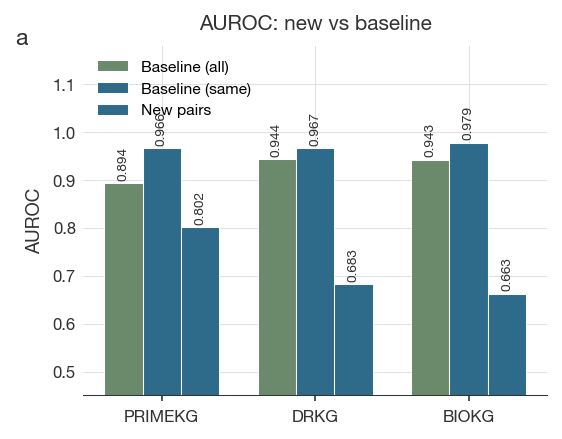

In [57]:

# Prospective generalization: AUROC baseline vs new pairs
shown_kgs = [n for n in LOADED
             if not np.isnan(temporal_metrics_kg.get(n, {}).get('auroc', np.nan))]

AUROC_BARS = [
    ('Baseline (all)',  baseline_all_kg,      OI_GREEN),
    ('Baseline (same)', baseline_same_kg,     OI_SKY_BLUE),
    ('New pairs',       temporal_metrics_kg,  OI_BLUE),
]
x = np.arange(len(shown_kgs))
w = 0.25

fig, ax = plt.subplots(figsize=(3.8, 3.0))
for i, (label, src, color) in enumerate(AUROC_BARS):
    vals = [src.get(n, {}).get('auroc', np.nan) for n in shown_kgs]
    bars = ax.bar(x + i * w, vals, w, label=label, color=color,
                  edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.006,
                    f'{v:.3f}', ha='center', va='bottom',
                    fontsize=6.5, fontweight='bold',
                    color=TEXT_COLOR, rotation=90)

ax.set_xticks(x + w)
ax.set_xticklabels([n.upper() for n in shown_kgs], fontsize=8.5)
ax.set_ylim(0.45, 1.18)
ax.legend(fontsize=7.5, frameon=False)
_style_left_spine(ax)
clean_ax(ax, title='AUROC: new vs baseline', ylabel='AUROC')
panel_label(ax, 'a')
plt.tight_layout()
save_fig(fig, FIGS, '07a_prospective_auroc')
plt.show()


  → Saved: 07b_prospective_hits_at_k.pdf / .png


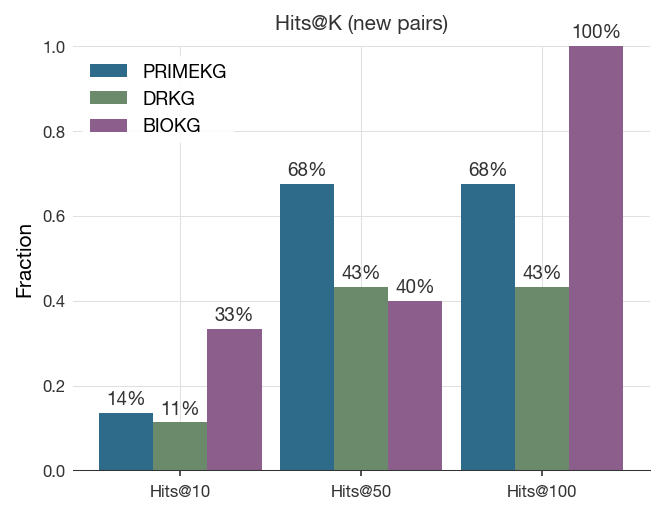

In [58]:
# Prospective generalization: Hits@K
K_KEYS   = ['hits@10', 'hits@50', 'hits@100']
K_LABELS = ['Hits@10', 'Hits@50', 'Hits@100']

# Only PrimeKG and DRKG have sufficient pairs
prospective_kgs = [n for n in shown_kgs if n in temporal_metrics_kg
                   and temporal_metrics_kg[n].get('hits@10') is not None]

x   = np.arange(len(K_KEYS))
w_h = 0.30

fig, ax = plt.subplots(figsize=(4.5, 3.5))
for i, name in enumerate(prospective_kgs):
    m    = temporal_metrics_kg.get(name, {})
    vals = [m.get(k, np.nan) for k in K_KEYS]
    bars = ax.bar(x + i * w_h, [v if not np.isnan(v) else 0 for v in vals], w_h,
                  label=name.upper(), color=KG_COLORS[name],
                  edgecolor='none', linewidth=0)
    for bar, v in zip(bars, vals):
        if not np.isnan(v) and v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f'{v:.0%}', ha='center', va='bottom',
                    fontsize=9, color=TEXT_COLOR)

ax.set_xticks(x + w_h * (len(prospective_kgs) - 1) / 2)
ax.set_xticklabels(K_LABELS, fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Fraction', fontsize=10)
ax.legend(fontsize=9, frameon=True, facecolor='white', edgecolor='none', framealpha=0.9)
_style_left_spine(ax)
clean_ax(ax, title='Hits@K (new pairs)')
plt.tight_layout()
save_fig(fig, FIGS, '07b_prospective_hits_at_k')
plt.show()

In [59]:
# Build percentile rank data for the rank distribution plot
pct_data = {}
all_pct = []
for name in temporal_ranks_kg:
    ranks = temporal_ranks_kg[name]
    n_total = temporal_metrics_kg[name].get('n_diseases', len(ranks))
    pct = 100.0 * ranks / max(n_total, 1)
    pct_data[name] = pct
    all_pct.extend(pct.tolist())

print(f'Percentile data built for {len(pct_data)} KGs: {list(pct_data.keys())}')


Percentile data built for 3 KGs: ['primekg', 'drkg', 'biokg']


  → Saved: 07c_prospective_rank_dist.pdf / .png


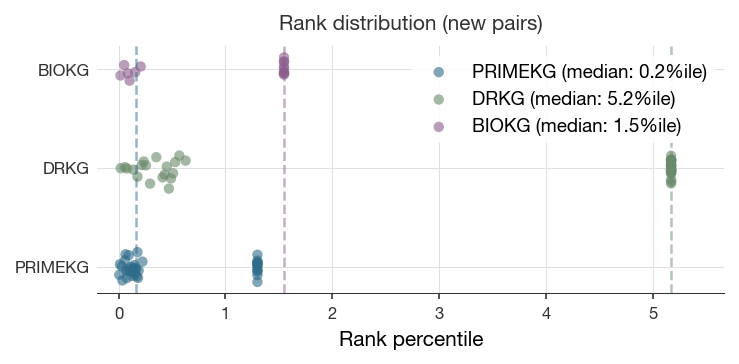

In [60]:
fig, ax = plt.subplots(figsize=(5, 2.5))

for i, (name, pct) in enumerate(pct_data.items()):
    med = np.median(pct)
    ax.scatter(pct, np.random.normal(i, 0.08, size=len(pct)),
               color=KG_COLORS[name], alpha=0.6, s=25, edgecolors='none',
               label=f'{name.upper()} (median: {med:.1f}%ile)')
    ax.axvline(med, color=KG_COLORS[name], ls='--', lw=1.2, alpha=0.5)

ax.set_yticks(range(len(pct_data)))
ax.set_yticklabels([n.upper() for n in pct_data.keys()], fontsize=10)
ax.set_xlabel('Rank percentile', fontsize=10)
ax.set_xlim(-0.2, max(all_pct) + 0.5)
_style_left_spine(ax)
clean_ax(ax, title='Rank distribution (new pairs)')
ax.legend(fontsize=9, frameon=True, facecolor='white', edgecolor='none', framealpha=0.9)
plt.tight_layout()
save_fig(fig, FIGS, '07c_prospective_rank_dist')
plt.show()

### Network proximity validation

Chandak et al. (2023) validated PrimeKG by showing that newly approved drugs sit
significantly closer to their indicated diseases than to random diseases in the
graph. We replicate this analysis across all five KGs using the FDA novel drug
approvals gold standard.

**Method.** For each drug–disease pair found in a KG, we compute the unweighted
shortest-path distance, then run a permutation test (1,000 random disease nodes)
to assess whether the true indication is significantly closer than expected by
chance. P-values are Bonferroni-corrected per KG.

In [61]:
# ── Network proximity validation ─────────────────────────────────────
# Replicates Chandak et al. (2023) Table 5 across all 5 KGs using the
# FDA novel drug approvals gold standard and existing NetworkX graphs.

import networkx as nx
import random, time

random.seed(42)
np.random.seed(42)

N_PERM = 1000

# Entity-type labels per KG (disease node type)
_DIS_TYPE = {
    'primekg': 'disease', 'hetionet': 'Disease', 'drkg': 'Disease',
    'openbilink': 'Disease', 'biokg': 'Disease',
}

all_proximity = {}

for kg_name in LOADED:
    t0 = time.time()
    G = graphs[kg_name]
    nodes_df = kgs[kg_name]['nodes']

    # ── All disease node indices (for permutation pool) ──
    dis_type = _DIS_TYPE.get(kg_name, 'Disease')
    all_dis_idxs = nodes_df[nodes_df['type'] == dis_type]['idx'].tolist()

    # ── Resolve FDA drug–disease pairs to graph node indices ──
    pairs = []
    seen  = set()
    for _, row in _fda.iterrows():
        db_id      = str(row['DrugBank_ID']).strip()
        indication = str(row['Indication']).strip()
        drug_name  = str(row['Active Ingredient']).strip()

        drug_idx = find_drug_in_kg(db_id, drug_name, kg_name)
        if drug_idx is None:
            continue

        dis_idx = find_disease_in_kg(indication, kg_name,
                                     disease_name_to_idx_kg[kg_name])
        if dis_idx is None:
            continue

        key = (drug_idx, dis_idx)
        if key in seen:          # avoid duplicate pairs
            continue
        seen.add(key)

        pairs.append({
            'drug': drug_name, 'db_id': db_id, 'indication': indication,
            'drug_idx': drug_idx, 'dis_idx': dis_idx,
        })

    print(f'\n{"=" * 70}')
    print(f'{kg_name.upper()}: {len(pairs)} testable drug\u2013disease pairs')
    print(f'{"=" * 70}')

    results = []
    for i, pair in enumerate(pairs):
        # Single-source BFS: O(V+E) once per drug
        dists = dict(nx.single_source_shortest_path_length(G, pair['drug_idx']))

        obs = dists.get(pair['dis_idx'])
        if obs is None:
            print(f"  {pair['drug']:35s}  DISCONNECTED")
            continue

        # Permutation pool: reachable diseases only
        pool = [d for d in all_dis_idxs if d in dists and d != pair['dis_idx']]
        if len(pool) < 100:
            print(f"  {pair['drug']:35s}  TOO FEW REACHABLE DISEASES ({len(pool)})")
            continue

        sample     = random.sample(pool, min(N_PERM, len(pool)))
        rand_dists = [dists[d] for d in sample]

        raw_p = sum(1 for d in rand_dists if d <= obs) / len(rand_dists)

        results.append({
            **pair,
            'obs_dist':        obs,
            'random_mean':     np.mean(rand_dists),
            'random_95ci_low': np.percentile(rand_dists, 2.5),
            'random_95ci_high':np.percentile(rand_dists, 97.5),
            'raw_p':           raw_p,
            'n_random':        len(rand_dists),
        })

        if (i + 1) % 25 == 0:
            print(f'  [{i+1}/{len(pairs)}] {time.time() - t0:.0f}s elapsed ...')

    # Bonferroni correction
    n_tested = len(results)
    for r in results:
        r['bonf_p']      = min(r['raw_p'] * n_tested, 1.0)
        r['significant'] = r['bonf_p'] <= 0.05

    elapsed = time.time() - t0
    n_sig   = sum(1 for r in results if r['significant'])
    print(f'\n  {n_tested} tested, {n_sig} significant '
          f'(Bonferroni \u2264 0.05)  [{elapsed:.1f}s]')

    all_proximity[kg_name] = results


PRIMEKG: 49 testable drug–disease pairs
  [25/49] 12s elapsed ...

  49 tested, 3 significant (Bonferroni ≤ 0.05)  [22.9s]

HETIONET: 0 testable drug–disease pairs

  0 tested, 0 significant (Bonferroni ≤ 0.05)  [0.3s]

DRKG: 55 testable drug–disease pairs
  [25/55] 17s elapsed ...
  [50/55] 34s elapsed ...
  aceclidine                           DISCONNECTED

  54 tested, 1 significant (Bonferroni ≤ 0.05)  [37.2s]

OPENBILINK: 13 testable drug–disease pairs

  13 tested, 3 significant (Bonferroni ≤ 0.05)  [4.6s]

BIOKG: 20 testable drug–disease pairs

  20 tested, 2 significant (Bonferroni ≤ 0.05)  [7.1s]


In [62]:
# ── Network proximity results tables ─────────────────────────────────
proximity_tables = {}

for kg_name in LOADED:
    results = all_proximity.get(kg_name, [])
    ok = [r for r in results if 'obs_dist' in r]
    if not ok:
        print(f'\n{kg_name}: no testable pairs')
        continue

    rows = []
    for r in sorted(ok, key=lambda x: (x['obs_dist'], x['bonf_p'])):
        rows.append({
            'Drug':        r['drug'],
            'Disease':     r['indication'],
            'Obs dist':    r['obs_dist'],
            'Rand mean':   round(r['random_mean'], 2),
            '95% CI':      f"[{r['random_95ci_low']:.1f}, {r['random_95ci_high']:.1f}]",
            'Raw P':       round(r['raw_p'], 4),
            'Bonf P':      round(r['bonf_p'], 4),
            'Sig':         '\u2713' if r['significant'] else '\u2717',
        })

    tbl  = pd.DataFrame(rows)
    proximity_tables[kg_name] = tbl
    n_sig = sum(1 for r in ok if r.get('significant'))

    print(f'\n{"=" * 90}')
    print(f'{kg_name.upper()}: {len(ok)} pairs tested, {n_sig} significant '
          f'(Bonferroni \u2264 0.05)')
    print(f'{"=" * 90}')
    display(tbl)

# ── Cross-KG summary ────────────────────────────────────────────────
print(f'\n{"=" * 90}')
print('CROSS-KG NETWORK PROXIMITY SUMMARY')
print(f'{"=" * 90}')

summary_rows = []
for kg_name in LOADED:
    res = all_proximity.get(kg_name, [])
    ok  = [r for r in res if 'obs_dist' in r]
    n_sig = sum(1 for r in ok if r.get('significant'))
    summary_rows.append({
        'KG':                   kg_name,
        'Pairs tested':         len(ok),
        'Significant':          n_sig,
        '% significant':        f'{100 * n_sig / len(ok):.0f}%' if ok else 'N/A',
        'Median obs dist':      int(np.median([r['obs_dist'] for r in ok])) if ok else None,
        'Median random mean':   round(np.median([r['random_mean'] for r in ok]), 2) if ok else None,
    })

display(pd.DataFrame(summary_rows).set_index('KG'))


PRIMEKG: 49 pairs tested, 3 significant (Bonferroni ≤ 0.05)


,Drug,Disease,Obs dist,Rand mean,95% CI,Raw P,Bonf P,Sig
0,gepirone,Major depressive disorder,1,3.49,"[2.0, 5.0]",0.001,0.049,✓
1,inclisiran,Familial hypercholesterolemia / ASCVD,2,4.63,"[4.0, 6.0]",0.000,0.000,✓
2,ganaxolone,CDKL5 deficiency disorder seizures,2,4.32,"[3.0, 6.0]",0.000,0.000,✓
3,oomidenepag isopropyl,Open-angle glaucoma / ocular hypertension,2,3.99,"[3.0, 6.0]",0.003,0.147,✗
4,mavorixafor,WHIM syndrome,2,4.38,"[3.0, 6.0]",0.003,0.147,✗
5,quizartinib,Newly diagnosed AML (FLT3-ITD),2,4.07,"[3.0, 6.0]",0.007,0.343,✗
6,elacestrant,ER+/HER2- ESR1-mutated advanced breast cancer,2,4.10,"[3.0, 6.0]",0.010,0.490,✗
7,sparsentan,IgA nephropathy,2,4.14,"[3.0, 6.0]",0.011,0.539,✗
8,lebrikizumab-lbkz,Moderate-to-severe atopic dermatitis,2,3.75,"[3.0, 5.0]",0.013,0.637,✗
9,adagrasib,KRAS G12C-mutated NSCLC,2,4.24,"[3.0, 6.0]",0.017,0.833,✗



hetionet: no testable pairs

DRKG: 54 pairs tested, 1 significant (Bonferroni ≤ 0.05)


,Drug,Disease,Obs dist,Rand mean,95% CI,Raw P,Bonf P,Sig
0,fexinidazole,Human African trypanosomiasis,1,3.71,"[3.0, 5.0]",0.000,0.000,✓
1,quizartinib,Newly diagnosed AML (FLT3-ITD),1,3.08,"[2.0, 4.0]",0.001,0.054,✗
2,momelotinib,Myelofibrosis with anemia,1,3.09,"[2.0, 4.0]",0.001,0.054,✗
3,treosulfan,AML/MDS (HSCT preparative regimen),1,3.12,"[3.0, 4.0]",0.001,0.054,✗
4,adagrasib,KRAS G12C-mutated NSCLC,2,3.63,"[3.0, 4.0]",0.010,0.540,✗
5,tirzepatide,Type 2 diabetes mellitus,2,2.80,"[2.0, 4.0]",0.376,1.000,✗
6,tapinarof,Plaque psoriasis,2,3.12,"[2.0, 4.0]",0.104,1.000,✗
7,terlipressin,Hepatorenal syndrome,2,2.83,"[2.0, 4.0]",0.340,1.000,✗
8,tremelimumab,Unresectable hepatocellular carcinoma,2,3.21,"[2.0, 4.0]",0.056,1.000,✗
9,mirvetuximab soravtansine-gynx,Recurrent platinum-resistant ovarian cancer,2,2.86,"[2.0, 4.0]",0.314,1.000,✗



OPENBILINK: 13 pairs tested, 3 significant (Bonferroni ≤ 0.05)


,Drug,Disease,Obs dist,Rand mean,95% CI,Raw P,Bonf P,Sig
0,gepirone,Major depressive disorder,1,4.24,"[3.0, 7.0]",0.000,0.000,✓
1,mavorixafor,WHIM syndrome,2,4.04,"[3.0, 6.0]",0.000,0.000,✓
2,sotagliflozin,Heart failure,2,4.14,"[3.0, 7.0]",0.001,0.013,✓
3,capivasertib,Breast cancer (AKT pathway),2,3.74,"[3.0, 6.0]",0.015,0.195,✗
4,quizartinib,Newly diagnosed AML (FLT3-ITD),2,3.81,"[3.0, 6.0]",0.017,0.221,✗
5,seladelpar,Primary biliary cholangitis,3,4.45,"[3.0, 6.0]",0.054,0.702,✗
6,terlipressin,Hepatorenal syndrome,3,3.72,"[2.0, 6.0]",0.496,1.000,✗
7,bexagliflozin,Type 2 diabetes mellitus,3,4.36,"[3.0, 7.0]",0.205,1.000,✗
8,momelotinib,Myelofibrosis with anemia,3,3.79,"[3.0, 6.0]",0.450,1.000,✗
9,mirdametinib,Neurofibromatosis type 1 (plexiform neurofibro...,3,3.77,"[3.0, 6.0]",0.463,1.000,✗



BIOKG: 20 pairs tested, 2 significant (Bonferroni ≤ 0.05)


,Drug,Disease,Obs dist,Rand mean,95% CI,Raw P,Bonf P,Sig
0,pacritinib,Myelofibrosis,1,3.58,"[2.0, 5.0]",0.000,0.00,✓
1,terlipressin,Hepatorenal syndrome,1,3.12,"[2.0, 5.0]",0.000,0.00,✓
2,mavorixafor,WHIM syndrome,2,4.32,"[3.0, 6.0]",0.003,0.06,✗
3,tapinarof,Plaque psoriasis,2,4.07,"[2.0, 6.0]",0.037,0.74,✗
4,ropeginterferon alfa-2b-njft,Polycythemia vera,2,3.22,"[2.0, 5.0]",0.284,1.00,✗
5,tezepelumab-ekko,Severe asthma,2,3.58,"[2.0, 5.0]",0.065,1.00,✗
6,sotagliflozin,Heart failure,2,3.14,"[2.0, 5.0]",0.332,1.00,✗
7,bimekizumab,Moderate-to-severe plaque psoriasis,2,3.55,"[2.0, 5.0]",0.061,1.00,✗
8,zavegepant,Migraine,3,4.74,"[4.0, 6.0]",0.012,0.24,✗
9,belzutifan,Von Hippel-Lindau disease,3,4.52,"[4.0, 6.0]",0.013,0.26,✗



CROSS-KG NETWORK PROXIMITY SUMMARY


,Pairs tested,Significant,% significant,Median obs dist,Median random mean
KG,,,,,
primekg,49,3,6%,2.0,3.76
hetionet,0,0,N/A,NaN,NaN
drkg,54,1,2%,3.0,3.22
openbilink,13,3,23%,3.0,4.06
biokg,20,2,10%,3.0,3.58


  → Saved: 07_network_proximity.pdf / .png


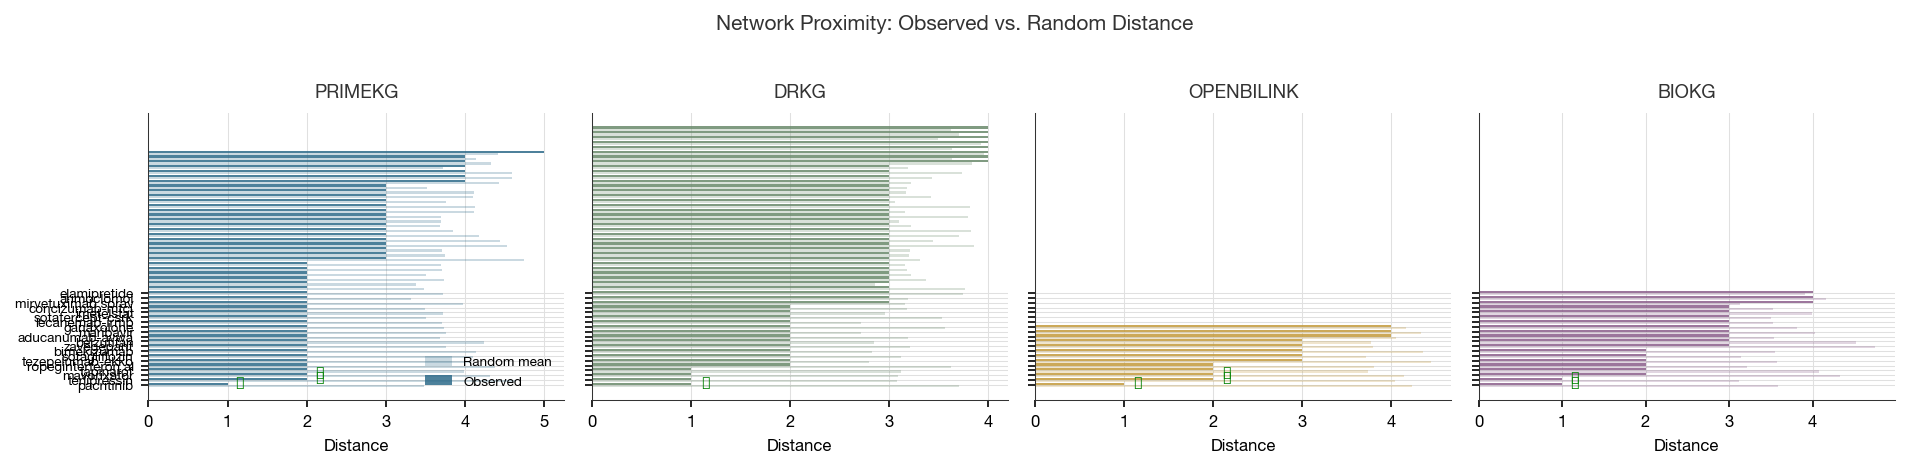

In [63]:
# ── Network proximity: observed vs. random distance per KG ───────────
shown_kgs = [n for n in LOADED if all_proximity.get(n)]
if shown_kgs:
    fig, axes = plt.subplots(1, len(shown_kgs),
                             figsize=(3.2 * len(shown_kgs), 3.0),
                             sharey=True, squeeze=False)
    axes = axes[0]

    for ax, kg_name in zip(axes, shown_kgs):
        ok = [r for r in all_proximity[kg_name] if 'obs_dist' in r]
        if not ok:
            ax.set_visible(False)
            continue

        obs_dists  = [r['obs_dist'] for r in ok]
        rand_means = [r['random_mean'] for r in ok]
        sig_mask   = [r['significant'] for r in ok]

        x = np.arange(len(ok))
        drug_labels = [r['drug'][:18] for r in
                       sorted(ok, key=lambda r: (r['obs_dist'], r['bonf_p']))]
        ok_sorted = sorted(ok, key=lambda r: (r['obs_dist'], r['bonf_p']))
        obs_s  = [r['obs_dist'] for r in ok_sorted]
        rand_s = [r['random_mean'] for r in ok_sorted]
        sig_s  = [r['significant'] for r in ok_sorted]

        color = KG_COLORS.get(kg_name, '#888888')

        ax.barh(x, rand_s, height=0.45, color=color, alpha=0.25, label='Random mean')
        ax.barh(x + 0.45, obs_s, height=0.45, color=color, alpha=0.85, label='Observed')

        # Mark significant pairs
        for j, (o, s) in enumerate(zip(obs_s, sig_s)):
            if s:
                ax.text(o + 0.1, j + 0.45, '\u2713', fontsize=8,
                        va='center', color='green', fontweight='bold')

        ax.set_yticks(x + 0.22)
        ax.set_yticklabels(drug_labels, fontsize=6.5)
        ax.set_xlabel('Distance', fontsize=8)
        ax.set_title(kg_name.upper(), fontsize=9, fontweight='bold',
                     color=TEXT_COLOR)
        ax.invert_yaxis()
        if ax == axes[0]:
            ax.legend(fontsize=6.5, loc='lower right')
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

    plt.suptitle('Network Proximity: Observed vs. Random Distance',
                 fontsize=10, fontweight='bold', y=1.02, color=TEXT_COLOR)
    plt.tight_layout()
    save_fig(fig, FIGS, '07_network_proximity')
    plt.show()

### Checkpoint

In [64]:
# Checkpoint — save scalar generalization results for downstream notebooks
CKPT_DIR = BASE / 'results' / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

def _scalars(metrics: dict) -> dict:
    '''Strip non-scalar values from a metrics dict.'''
    return {k: float(v) for k, v in metrics.items()
            if isinstance(v, (int, float)) and not hasattr(v, '__len__')}

def _safe_mean(vals):
    '''Mean of non-NaN values, or NaN if empty.'''
    clean = [v for v in vals if not (isinstance(v, float) and np.isnan(v))]
    return np.mean(clean) if clean else np.nan

# ── Sub-scores (one per generalisation axis) ──────────────────────────
sub_scores = {}
for name in LOADED:
    # 1. Data-sparse: Q1 (sparse tier) AUROC
    q1_auroc = tier_results_kg.get(name, {}).get('Q1: Sparse', {}).get('auroc', np.nan)

    # 2. Cross-domain: mean AUROC across therapeutic areas
    area_aurocs = [
        m.get('auroc', np.nan)
        for m in area_results_kg.get(name, {}).values()
        if not np.isnan(m.get('auroc', np.nan))
    ]
    cd_auroc = np.mean(area_aurocs) if area_aurocs else np.nan

    # 3. Prospective: AUROC on post-cutoff FDA approval pairs
    #    NaN if KG had fewer than MIN_PAIRS evaluable pairs (unreliable estimate)
    tmp_auroc = temporal_metrics_kg.get(name, {}).get('auroc', np.nan)

    sub_scores[name] = {
        'data_sparse_gen':  round(float(q1_auroc), 4)  if not np.isnan(q1_auroc)  else np.nan,
        'cross_domain_gen': round(float(cd_auroc), 4)   if not np.isnan(cd_auroc)  else np.nan,
        'temporal_gen':     round(float(tmp_auroc), 4)  if not np.isnan(tmp_auroc) else np.nan,
    }

# ── Summary: mean of available sub-scores (NaN sub-scores excluded) ──
summary_scores = {
    name: round(float(_safe_mean(list(ss.values()))), 4)
    for name, ss in sub_scores.items()
}

ckpt = {
    'summary_scores': summary_scores,
    'sub_scores':     sub_scores,
    'tier_scalars':   {name: {tier: _scalars(m) for tier, m in tiers.items()}
                       for name, tiers in tier_results_kg.items()},
    'area_scalars':   {name: {area: _scalars(m) for area, m in areas.items()}
                       for name, areas in area_results_kg.items()},
    'area_cv':        {name: float(v) for name, v in area_cv.items()},
}

out = CKPT_DIR / '07_generalization.pkl'
with open(out, 'wb') as f:
    pickle.dump(ckpt, f)

print(f'Checkpoint saved: {out}')
print(f'\n{"KG":12s}  {"Sparse":>8s}  {"X-Domain":>8s}  {"Prospective":>11s}  {"Summary":>8s}')
print('-' * 56)
for name in LOADED:
    ss = sub_scores[name]
    prosp = f'{ss["temporal_gen"]:.4f}' if not np.isnan(ss["temporal_gen"]) else 'N/A'
    print(f'  {name:12s}  {ss["data_sparse_gen"]:.4f}    {ss["cross_domain_gen"]:.4f}    '
          f'{prosp:>11s}    {summary_scores[name]:.4f}')

Checkpoint saved: /Users/shil6661/biokgsuite/results/checkpoints/07_generalization.pkl

KG              Sparse  X-Domain  Prospective   Summary
--------------------------------------------------------
  primekg       0.6905    0.9676         0.8023    0.8201
  hetionet      0.7835    0.8881            N/A    0.8358
  drkg          0.5607    0.9539         0.6829    0.7325
  openbilink    0.6416    0.8368            N/A    0.7392
  biokg         0.6749    0.8905         0.6627    0.7427


## Dimension Score

The **Generalisation** dimension score aggregates three complementary axes, each
measured as an AUROC in $[0, 1]$:

| Sub-score | Metric | Rationale |
|-----------|--------|-----------|
| **Data-sparse generalisation** | AUROC on Q1 (sparse-tier) diseases | Measures performance on rare / under-represented diseases — the hardest generalisation setting |
| **Cross-domain generalisation** | Mean AUROC across therapeutic areas | Captures whether predictive power is consistent across disease domains |
| **Prospective generalisation** | AUROC on post-cutoff FDA approvals | Tests prospective validity — whether the KG predicts indications approved after its data freeze |

$$
S_{\text{gen}}(g) \;=\; \frac{1}{3}\!\left(
   \text{AUROC}_{\text{Q1}}(g)
   \;+\; \overline{\text{AUROC}}_{\text{area}}(g)
   \;+\; \text{AUROC}_{\text{prospective}}(g)
\right)
$$

All sub-scores are saved in `sub_scores[kg]` for the summary heatmap in notebook 00.